# **Desarrollo de Actividad 2 - Curso de Análisis estadístico para modelos no supervisados**


**Proyecto:** Generación de clusters basadas en patrones de prácticas de gestión del agua residual de industrias basada en la Encuesta Ambiental Industrial del año 2023.

**Presentado por:**

•	Adriana Patricia Rodriguez Toloza

**Fecha:** 05 de mayo de 2026


## **Selección del conjunto de datos y comprensión del contexto:**



Para realizar este ejercicio, se decidió tomar la base de datos la **"Encuesta Ambiental Industrial (EAI)"** del año 2023 realizada por el **DANE**, la cual, contiene información estadística relacionada a la gestión ambiental realizada por establecimientos industriales que ya hacían parte de la Encuesta Anual Manufacturera. De acuerdo con el DANE, la  La EAI es utilizada para identificar patrones y tendencias en gestión ambiental y el seguimiento de resultados de las políticas públicas en el sector industrial del país.

La encuesta se encuentra constituido por seis capitulos, sin embargo, para el presente proyecto se utilizará el capitulo 4 relacionadas a las prácticas de gestión del recurso hídrico permitiendo segmentar empresas por la gestión de sus vertimientos.

* **¿Qué variables incluye el estudio?**
Para el presente proyecto se utilizarán únicamente las siguientes varibles de interés:

* **Capitulo 4:** prácticas relacionadas a la gestión del recurso hídrico.
  * **CODIGO_REGISTRO:** Código único de identificación de las fuentes anonimizado
  * **CODIGO_ACTIVIDAD:** Código de los grupos de divisiones industriales
  * **CODIGO_REGION:** Código región
  * **C3RH2VTC:** Volumen de agua total utilizada por el establecimiento (m3/año)
  * **C3RH3VTR:** Volumen total de aguas residuales generadas por el establecimiento (m3/año)
  * **C3RH3VCT:** Volumen de agua residual tratada y vertida
  * **C3RH3VAT:** Volumen de agua residual tratada por el establecimiento (m3/año)
  * **VOAGETTRAT:** Volumen de agua residual entregado a un tercero para su tratamiento
  * **C3RH3VST:** Volumen de agua residual vertida sin tratamiento (a+b)
  * **C3RH3VSTA:** Volumen de agua vertida sin tratamiento a Sistemas de Alcantarillado  (m3/año)
  * **C3RH3VSTO:** b. Volumen de agua vertida sin tratamiento a otro medio receptor  (m3/año)
  * **C3RH3VARC:** Volumen de agua recirculada por el establecimiento  (m3/año)



## **Formulación del problema:**

La base de datos contiene información de 3679 industrias en Colombia que abarcan 22 tipos de industria. Sin embargo, se plantea la inquietud si es posible agrupar las industrias con base a la gestión del recurso hídrico, por lo cual se plantea la siguiente pregunta:

**¿Cómo se pueden agrupar las industrias en Colombia de acuerdo con las prácticas de gestión del recurso hídrico que implementan?**

## **Paso 1: Cargue de información:**

### ***1.1 Importar librerias:***

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import skew,kurtosis

### ***1.2 Conectar el drive:***

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### ***1.3 Lectura de bases de datos CSV:***

In [3]:
df=pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/No supervisados/Actividad 2/ANONIMIZADO_CAP4_23.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3679 entries, 0 to 3678
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CODIGO_REGISTRO   3679 non-null   int64  
 1   CODIGO_ACTIVIDAD  3679 non-null   int64  
 2   CODIGO_REGION     3679 non-null   int64  
 3   FACTOR_EXPANSION  3679 non-null   float64
 4   C3RH1PR           3679 non-null   object 
 5   REGAGCONSUM       3679 non-null   object 
 6   REGAGVERTID       3679 non-null   object 
 7   C3RH2VTC          3679 non-null   int64  
 8   C3RH2VEA          3679 non-null   int64  
 9   C3RH2VPP          3679 non-null   int64  
 10  C3RH2VAS          3679 non-null   int64  
 11  C3RHLLUV          3679 non-null   int64  
 12  C3RH2VOC          3679 non-null   int64  
 13  C3RH3VTR          3679 non-null   int64  
 14  C3RH3VCT          3679 non-null   int64  
 15  C3RH3VCTA         3679 non-null   int64  
 16  C3RH3VCTO         3679 non-null   int64  


Con el método .info() es posible observar que al unir los dos capitulos de interés que conforman la base de datos, obtenemos un total de 164 variables. Es por esta razón que resultó importante centralizar y enfocarnos únicamente en las variables de interés.

### ***1.5 Extracción de variables de interés:***


In [5]:
df.columns

Index(['CODIGO_REGISTRO', 'CODIGO_ACTIVIDAD', 'CODIGO_REGION',
       'FACTOR_EXPANSION', 'C3RH1PR', 'REGAGCONSUM', 'REGAGVERTID', 'C3RH2VTC',
       'C3RH2VEA', 'C3RH2VPP', 'C3RH2VAS', 'C3RHLLUV', 'C3RH2VOC', 'C3RH3VTR',
       'C3RH3VCT', 'C3RH3VCTA', 'C3RH3VCTO', 'C3RH3VST', 'C3RH3VSTA',
       'C3RH3VSTO', 'VOAGETTRAT', 'C3RH3VAT', 'C3RH3VAT0', 'C3RH3VAT1',
       'C3RH3VAT2', 'C3RH3VAT3', 'C3RH3VAT4', 'C3RH3VARC'],
      dtype='object')

In [6]:
df=df[["CODIGO_REGISTRO","CODIGO_ACTIVIDAD","CODIGO_REGION","C3RH2VTC","C3RH3VTR","C3RH3VCT","C3RH3VST","C3RH3VSTA","C3RH3VSTO","VOAGETTRAT","C3RH3VAT","C3RH3VARC"]]

### ***1.6 Renombre de variables de interés:***

In [7]:
df.rename(columns={"C3RH2VTC":"Volumen de agua total utilizada por el establecimiento (m3/año)",
                   "C3RH3VTR": "Volumen total de aguas residuales generadas por el establecimiento (m3/año)",
                   "C3RH3VCT": "Volumen de agua residual tratada y vertida (m3/año)",
                   "C3RH3VAT": "Volumen de agua residual tratada por el establecimiento (m3/año)",
                   "C3RH3VST": "Volumen de agua residual vertida sin tratamiento (a+b)",
                   "VOAGETTRAT": "Volumen de agua residual entregado a un tercero para su tratamiento (m3/año)",
                   "C3RH3VSTA": "a. Volumen de agua vertida sin tratamiento. Sistemas de Alcantarillado (m3/año)",
                   "C3RH3VSTO": "b. Volumen de agua vertida sin tratamiento a otro medio receptor (m3/año)",
                   "C3RH3VARC": "Volumen de agua recirculada por el establecimiento (m3/año)"},
          inplace=True)

In [8]:
df.head(100)

,CODIGO_REGISTRO,CODIGO_ACTIVIDAD,CODIGO_REGION,Volumen de agua total utilizada por el establecimiento (m3/año),Volumen total de aguas residuales generadas por el establecimiento (m3/año),Volumen de agua residual tratada y vertida (m3/año),Volumen de agua residual vertida sin tratamiento (a+b),a. Volumen de agua vertida sin tratamiento. Sistemas de Alcantarillado (m3/año),b. Volumen de agua vertida sin tratamiento a otro medio receptor (m3/año),Volumen de agua residual entregado a un tercero para su tratamiento (m3/año),Volumen de agua residual tratada por el establecimiento (m3/año),Volumen de agua recirculada por el establecimiento (m3/año)
0,145879,15,2,68295,63990,63217,0,0,0,773,63217,0
1,866074,7,5,127,127,0,127,127,0,0,0,0
2,981718,17,2,897,489,0,489,489,0,0,0,0
3,975767,4,3,2052,2052,0,866,866,0,1186,0,0
4,143575,81,3,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
95,978642,7,3,203558,16619,16619,0,0,0,0,16619,0
96,975956,8,3,2752,2697,2697,0,0,0,0,2697,0
97,986269,17,5,1436,1005,0,1005,1005,0,0,0,0
98,142126,6,1,681652,486567,170143,65211,65211,0,251213,235355,564259


## **Paso 2: Exploración inicial de los datos:**

### ***2.1 Identificación de los tipos de variables seleccionadas***

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3679 entries, 0 to 3678
Data columns (total 12 columns):
 #   Column                                                                           Non-Null Count  Dtype
---  ------                                                                           --------------  -----
 0   CODIGO_REGISTRO                                                                  3679 non-null   int64
 1   CODIGO_ACTIVIDAD                                                                 3679 non-null   int64
 2   CODIGO_REGION                                                                    3679 non-null   int64
 3   Volumen de agua total utilizada por el establecimiento (m3/año)                  3679 non-null   int64
 4   Volumen total de aguas residuales generadas por el establecimiento (m3/año)      3679 non-null   int64
 5   Volumen de agua residual tratada y vertida (m3/año)                              3679 non-null   int64
 6   Volumen de agua residual

Mediante el método .info() observamos que nuestra base de datos se compone de 3679 registros y 12 variables, 3 de ellas identificatorias.
Las 18 variables son cuantitativas discretas.

### ***2.2 Medidas estadísticas de centralidad, localización, variabilidad y forma:***

In [10]:
#Variables numericas de análisis

variables_numericas=['Volumen de agua total utilizada por el establecimiento (m3/año)',
                     'Volumen total de aguas residuales generadas por el establecimiento (m3/año)',
                     'Volumen de agua residual tratada y vertida (m3/año)',
                     "Volumen de agua residual vertida sin tratamiento (a+b)",
                     'a. Volumen de agua vertida sin tratamiento. Sistemas de Alcantarillado (m3/año)',
                     'b. Volumen de agua vertida sin tratamiento a otro medio receptor (m3/año)',
                     'Volumen de agua residual entregado a un tercero para su tratamiento (m3/año)',
                     'Volumen de agua residual tratada por el establecimiento (m3/año)',
                     "Volumen de agua recirculada por el establecimiento (m3/año)"]



In [11]:
df[variables_numericas].describe().round(2)

,Volumen de agua total utilizada por el establecimiento (m3/año),Volumen total de aguas residuales generadas por el establecimiento (m3/año),Volumen de agua residual tratada y vertida (m3/año),Volumen de agua residual vertida sin tratamiento (a+b),a. Volumen de agua vertida sin tratamiento. Sistemas de Alcantarillado (m3/año),b. Volumen de agua vertida sin tratamiento a otro medio receptor (m3/año),Volumen de agua residual entregado a un tercero para su tratamiento (m3/año),Volumen de agua residual tratada por el establecimiento (m3/año),Volumen de agua recirculada por el establecimiento (m3/año)
count,3679.00,3679.00,3679.0,3679.00,3679.00,3679.00,3679.00,3679.00,3679.00
mean,76966.45,45027.12,40623.1,3747.99,1522.30,2225.69,656.03,50956.48,164052.81
std,580919.30,416641.52,410309.0,52978.50,5098.35,52792.30,8220.81,534871.51,2708790.20
min,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00
25%,444.50,310.50,0.0,0.00,0.00,0.00,0.00,0.00,0.00
50%,1760.00,1132.00,0.0,264.00,227.00,0.00,0.00,0.00,0.00
75%,11087.50,5173.00,2286.5,1153.50,1070.50,0.00,0.00,3083.50,0.00
max,17043278.00,15967667.00,15967667.0,1564690.00,97337.00,1564690.00,251213.00,18869195.00,75786077.00


In [12]:
#Medidas de variabilidad
fila_var=[]
for col in variables_numericas:
  varianza=df[col].var()
  desviacion=df[col].std()
  coeficiente_variacion=(100*(df[col].std()/df[col].mean())).round(2)
  fila_var.append({"Variable:":col,
                   "Varianza:":varianza,
                   "Desviación estándar":desviacion,
                   "Coeficiente de variación:":coeficiente_variacion})
fila_var=pd.DataFrame(fila_var)
fila_var


,Variable:,Varianza:,Desviación estándar,Coeficiente de variación:
0,Volumen de agua total utilizada por el estable...,3.374672e+11,5.809193e+05,754.77
1,Volumen total de aguas residuales generadas po...,1.735902e+11,4.166415e+05,925.31
2,Volumen de agua residual tratada y vertida (m3...,1.683535e+11,4.103090e+05,1010.04
3,Volumen de agua residual vertida sin tratamien...,2.806722e+09,5.297850e+04,1413.52
4,a. Volumen de agua vertida sin tratamiento. Si...,2.599317e+07,5.098349e+03,334.91
5,b. Volumen de agua vertida sin tratamiento a o...,2.787027e+09,5.279230e+04,2371.95
6,Volumen de agua residual entregado a un tercer...,6.758170e+07,8.220809e+03,1253.12
7,Volumen de agua residual tratada por el establ...,2.860875e+11,5.348715e+05,1049.66
8,Volumen de agua recirculada por el establecimi...,7.337544e+12,2.708790e+06,1651.17


**Medidas de centralidad:**
Con el método .describe() obtenemos un resumen de medidas de centralidad, localización y de variabilidad importantes, permitiendo identificar:

*   La media de cada una de las variables de estudio es mayor que la mediana de manera significativa, reflejando asimetria y un sesgo hacia valores altos. Con la media > mediana permite identificar valores altos que afectan el valor promedio, en este caso, mostrando una asimetria positiva (cola hacia la derecha).

**Medidas de localización:**
* Se evidencia valores mínimos factibles (no negativos), sin embargo, se evidencia valores máximos de gran magnitud con relación al mínimo, generando un rango importante en cada variable.
* Se observa saltos entre cuartiles demasiado altos, especialmente entre el cuartil q3 (75%) y q4 (100%), reflejando la alta dispersión indicada mediante la desviación estandar y posibles outliers de manera significativa.

**Medidas de variabilidad**
*   Se evidencia una alta dispersión en cada una de las variables de análisis, permitiendo identificar que los datos están dispersos y alejados del promedio. Esto es un indicativo de alta heterogeneidad en los datos. Por lo cual, la media no es una medida que represente de manera efectiva a los datos.
* El coeficiente de variación refleja la alta dispersión de los datos con relación a la media.



**Medidas de forma:**

In [13]:
fila=[]
for col in variables_numericas:
      asimetria=df[col].skew()
      kurtosis=df[col].kurtosis()
      fila.append({"Variable:":col,
                   "Asimetria:":asimetria,
                   "Kurtosis:":kurtosis})
fila=pd.DataFrame(fila)
fila

,Variable:,Asimetria:,Kurtosis:
0,Volumen de agua total utilizada por el estable...,18.964443,448.020675
1,Volumen total de aguas residuales generadas po...,26.104312,827.636824
2,Volumen de agua residual tratada y vertida (m3...,27.170417,879.894312
3,Volumen de agua residual vertida sin tratamien...,28.109834,819.619327
4,a. Volumen de agua vertida sin tratamiento. Si...,9.140620,114.794299
5,b. Volumen de agua vertida sin tratamiento a o...,28.486813,834.556626
6,Volumen de agua residual entregado a un tercer...,25.239252,725.354246
7,Volumen de agua residual tratada por el establ...,24.938731,730.386140
8,Volumen de agua recirculada por el establecimi...,23.605217,605.621817


**Estándares para interpretación de las medidas de forma:**
* **Asimetría:**
  * Si el coeficiente < 0 significa que tiene distribución asimetrica negativa, y se alarga a valores menores que la media
  * Si el coeficiente == 0 significa que la distribución es simétrica
  * Si el coeficiente > 0 la distribución tiene asimetria positiva, y se alarga a valores mayores que la media
* **Curtosis:**
  * Si g2 < 0 la distribución es Platicúrtica
  * Si g2 = 0 la distribución es Mesocúrtica
  * Si g2 > 0 la distribución es Leptocúrtica

En este caso, el coeficiente de asimetria nos indica que todas las variables son asimétricas positiva (cola a la derecha). Mientras que la kurtosis >0 indica que son leptocúrtica, es decir con un elevamiento o pico agudo.

### ***2.3 Análisis de distribución y posibles outliers:***

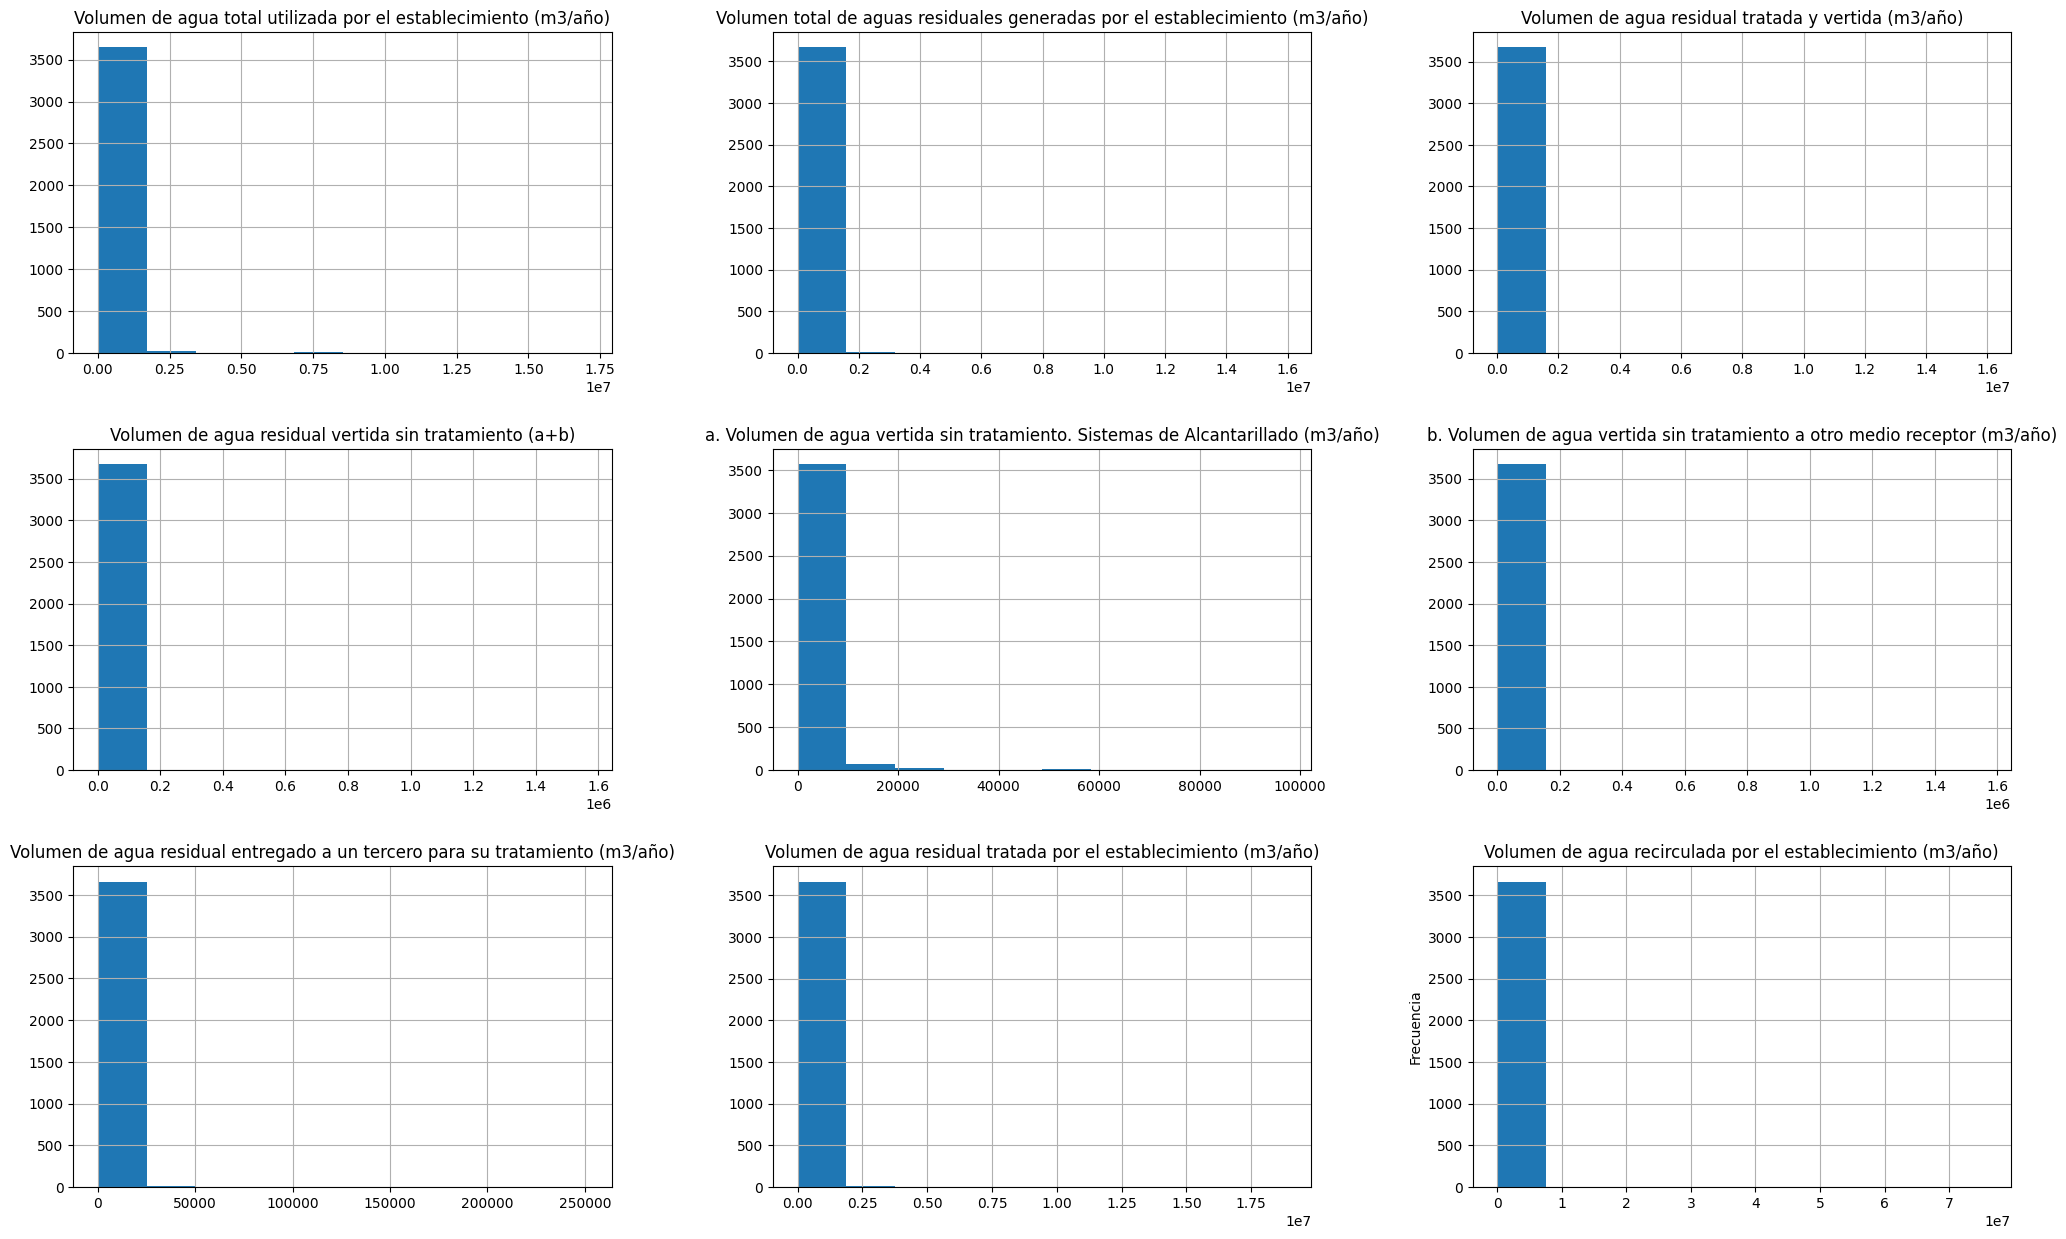

In [14]:
#Histogramas
df[variables_numericas].hist(figsize=(25,15))
plt.ylabel("Frecuencia")
plt.show()

Los histogramas muestran la asimetria positiva (cola a la derecha) de las variables. Se evidencia que la mayoria de las industrias presentan volumenes de agua residual, vertida, tratada o recirculada cercanos, sin embargo, la presencia de outliers o industrias con volumenes tan altos generan la distorsión del promedio.

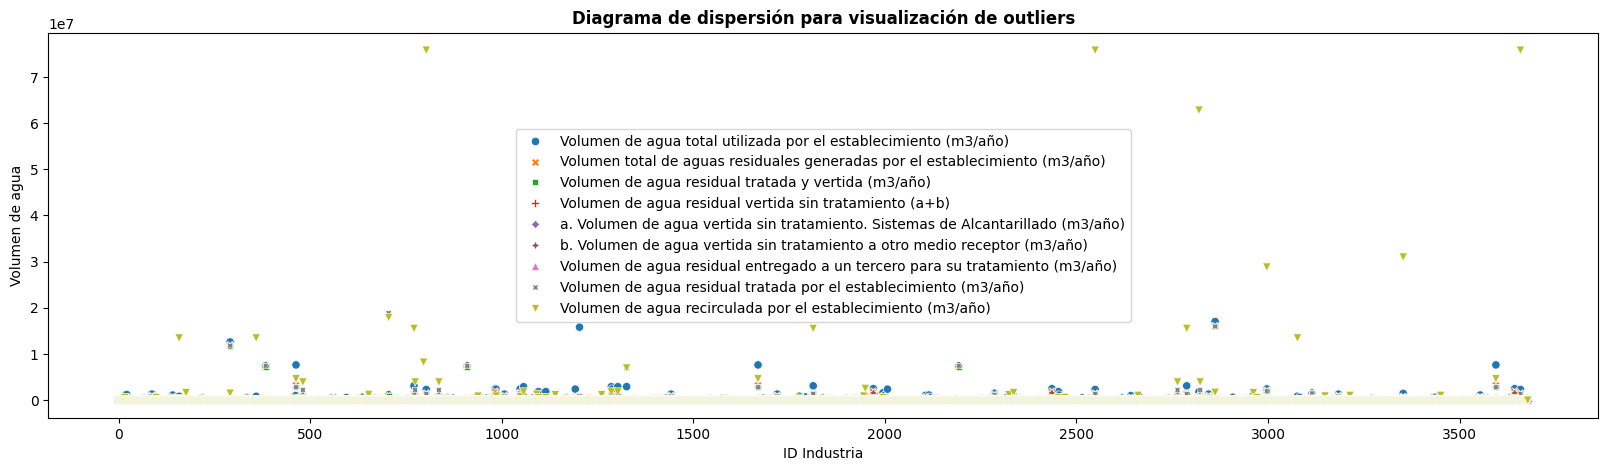

In [15]:
#Diagrama de dispersión de todas las variables
plt.figure(figsize=(20,5))
sns.scatterplot(df[variables_numericas])
plt.title("Diagrama de dispersión para visualización de outliers", fontweight="bold")
plt.xlabel("ID Industria")
plt.ylabel("Volumen de agua")
plt.show()

Con el diagrama de dispersión es posible determinar las existencia ee valores atipicos de gran magnitud.

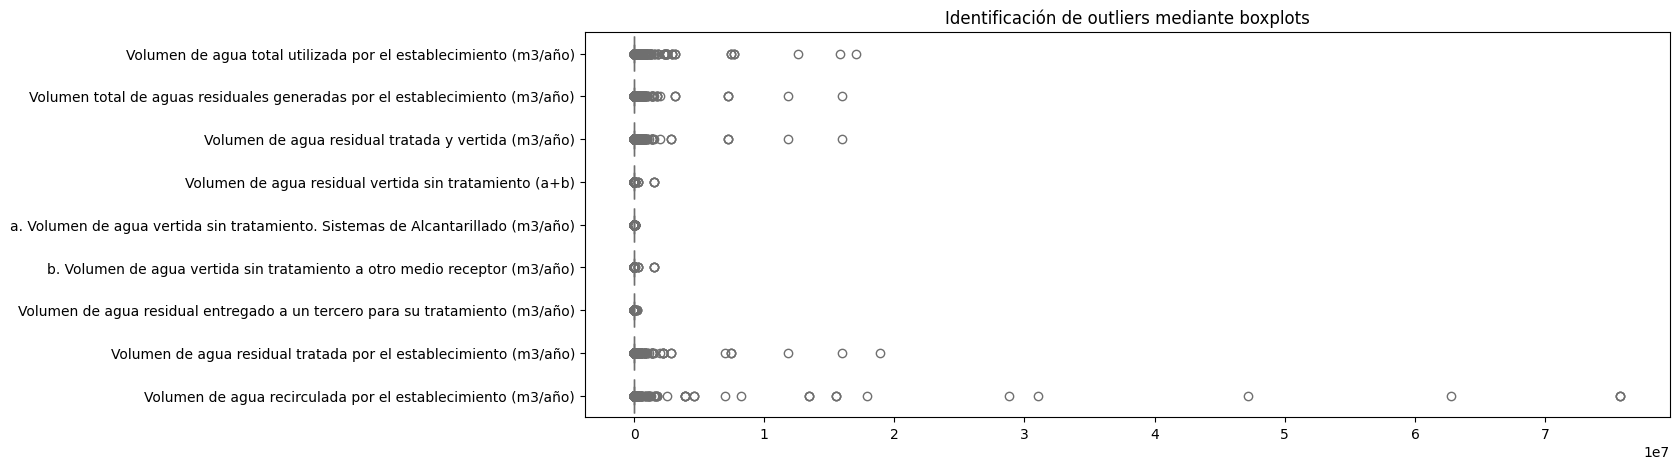

In [16]:
#Boxplots
plt.figure(figsize=(14,5))
sns.boxplot(df[variables_numericas],orient="h",palette="pastel")
plt.title("Boxplot de variables numéricas",fontweight="bold")
plt.title("Identificación de outliers mediante boxplots")
plt.show()

Se identifican algunos outliers importantes a tratar, donde el volumen de agua recirculada (tratada y recirculada) y el volumen de agua tratada son mayores que el volumen de agua utilizada por el establecimiento. Esto puede tratarse de un error en el registro de los datos al no cumplirse la ley de la conservación de la masa, por lo cual requiere verificación:

In [17]:
#Conteo y extracción de registros de posibles errores:
fila_conteo=[]
for col in variables_numericas:
  conteo=(df[col]>df["Volumen de agua total utilizada por el establecimiento (m3/año)"]).sum()
  fila_conteo.append({"Variable:":col,
               "Registros erroneos:":conteo})
fila_conteo=pd.DataFrame(fila_conteo)
fila_conteo

,Variable:,Registros erroneos:
0,Volumen de agua total utilizada por el estable...,0
1,Volumen total de aguas residuales generadas po...,68
2,Volumen de agua residual tratada y vertida (m3...,13
3,Volumen de agua residual vertida sin tratamien...,4
4,a. Volumen de agua vertida sin tratamiento. Si...,4
5,b. Volumen de agua vertida sin tratamiento a o...,0
6,Volumen de agua residual entregado a un tercer...,1
7,Volumen de agua residual tratada por el establ...,41
8,Volumen de agua recirculada por el establecimi...,89


Mediante el cocnteo evidenciamos varios registros donde el volumen de agua (residual, tratada, vertida sin tratamiento, recirculada) es mayor que el registro del volumen de agua registrada que utiliza la empresa (entrada). Para lo cual, surge la necesidad de identificar y analizar estos registros.

In [18]:
#Registros con valores mayores al volumen de agua utilizada por el establecimiento
lista_indices=[]
for col in variables_numericas:
  indice=(df[df[col]>df["Volumen de agua total utilizada por el establecimiento (m3/año)"]]).index.tolist()
  lista_indices.extend(indice)

lista_indices=list(set(lista_indices)) #Indice de registros que no cumplen la condición, evaluada por cada variables, y quitando duplicados que pudieron presentarse entre dos o más variables
print("Registros en la cual el volumen de agua de salida (tratada, vertida o recirculada) es mayor que el volumen de agua que entró al sistema")
df.loc[lista_indices]


Registros en la cual el volumen de agua de salida (tratada, vertida o recirculada) es mayor que el volumen de agua que entró al sistema


,CODIGO_REGISTRO,CODIGO_ACTIVIDAD,CODIGO_REGION,Volumen de agua total utilizada por el establecimiento (m3/año),Volumen total de aguas residuales generadas por el establecimiento (m3/año),Volumen de agua residual tratada y vertida (m3/año),Volumen de agua residual vertida sin tratamiento (a+b),a. Volumen de agua vertida sin tratamiento. Sistemas de Alcantarillado (m3/año),b. Volumen de agua vertida sin tratamiento a otro medio receptor (m3/año),Volumen de agua residual entregado a un tercero para su tratamiento (m3/año),Volumen de agua residual tratada por el establecimiento (m3/año),Volumen de agua recirculada por el establecimiento (m3/año)
3077,982023,7,2,853540,142915,142915,0,0,0,0,169876,13468547
3597,982043,3,5,46676,46685,36250,10426,10426,0,9,36250,0
529,146621,91,3,37008,26515,21697,4388,4388,0,430,21718,226222
3099,865397,17,2,27687,7218,809,3256,3256,0,3153,116332,99379
542,147472,6,3,555,565,555,0,0,0,10,555,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1010,984086,3,2,8247,6802,6792,0,0,0,10,19670,12878
2033,142259,51,3,15943,14348,14348,0,0,0,0,19988,5640
2549,979213,17,4,2327110,1387350,1387350,0,0,0,0,1387350,75786077
2553,143699,4,5,319,320,0,319,319,0,1,0,1


Se encuentra que 160 registros tienen alguna de las variables de salida mayor que la de entrada (Volumen de agua utilizada por el establecimiento (m3/año)). Al incumplir el criterio de balance de masa, se considerará como un criterio de error.


**%registro con error**= (160/3679)*100 = 4.34% del total de datos, por lo cual, se recomienda eliminar.

##### ***2.3.1 Eliminación de los 160 registros con datos erroneos:***

In [19]:
print("Cantidad de registros antes de eliminar:",df.shape[0])

Cantidad de registros antes de eliminar: 3679


In [20]:
df=df.drop(lista_indices)

In [21]:
print("Cantidad de registros despues de eliminar:",df.shape[0])

Cantidad de registros despues de eliminar: 3519


In [22]:
#Verificación
lista=[]
for col in variables_numericas:
  conteo=(df[col]>df["Volumen de agua total utilizada por el establecimiento (m3/año)"]).sum()
  lista.append({"Variable:":col,
                "Registros erroneos:":conteo})
lista=pd.DataFrame(lista)
lista

,Variable:,Registros erroneos:
0,Volumen de agua total utilizada por el estable...,0
1,Volumen total de aguas residuales generadas po...,0
2,Volumen de agua residual tratada y vertida (m3...,0
3,Volumen de agua residual vertida sin tratamien...,0
4,a. Volumen de agua vertida sin tratamiento. Si...,0
5,b. Volumen de agua vertida sin tratamiento a o...,0
6,Volumen de agua residual entregado a un tercer...,0
7,Volumen de agua residual tratada por el establ...,0
8,Volumen de agua recirculada por el establecimi...,0


Podemos visualizar mediante un diagra de dispersión que se cumpla el criterio establecido, donde el volumen de agua utilizada por el establecimiento no debe ser menor que las demás variables.

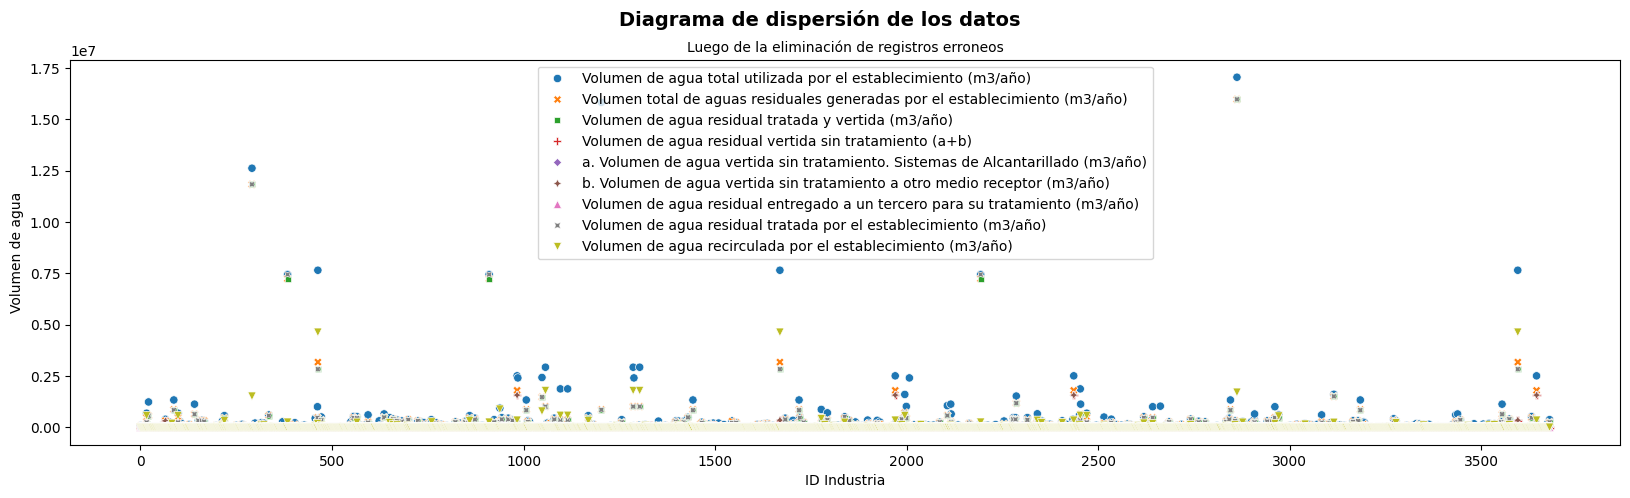

In [23]:
#Diagrama de dispersión de los datos luego de eliminado los registros erroneos
plt.figure(figsize=(20,5))
sns.scatterplot(df[variables_numericas])
plt.suptitle("Diagrama de dispersión de los datos", fontweight="bold",fontsize=14)
plt.title("Luego de la eliminación de registros erroneos",fontsize=10)
plt.xlabel("ID Industria")
plt.ylabel("Volumen de agua")
plt.show()

Luego de realizada la eliminación de los 160 registros con valores erroneos se observa mediante el gráfico de dispersión que el rango de las variables disminuyó.
Vemos también registros con outliers significativos, los cuales representan empresas que por su actividad industrial y tamaño consumen altas cantidades de agua.

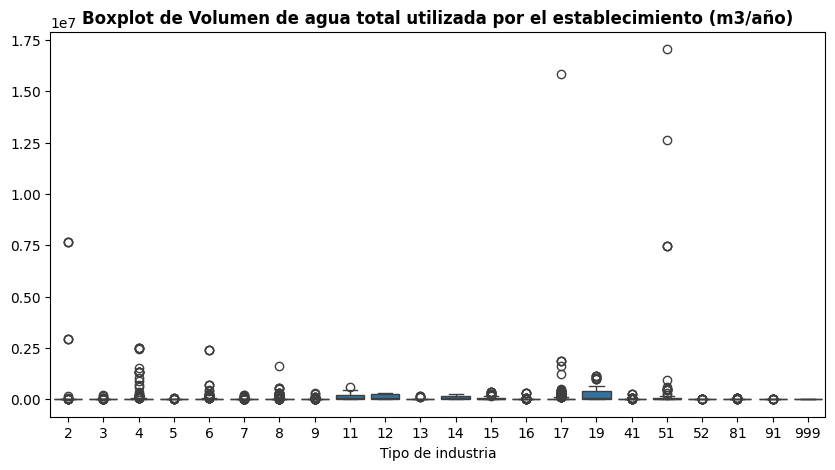

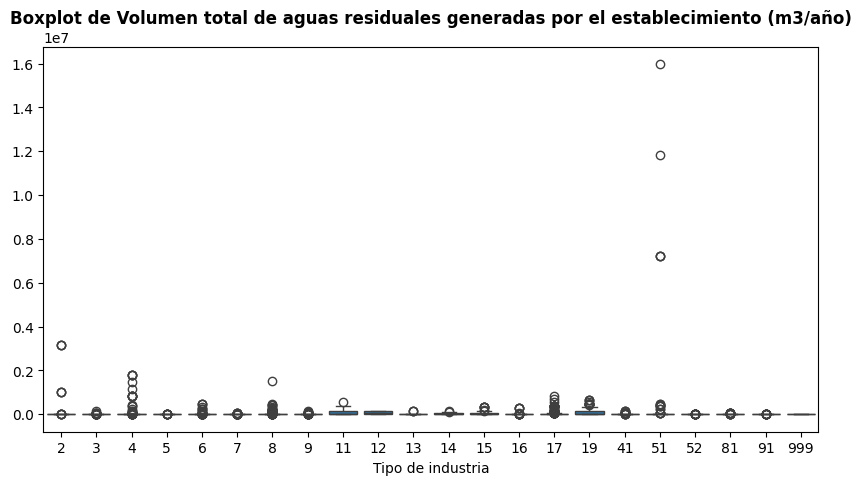

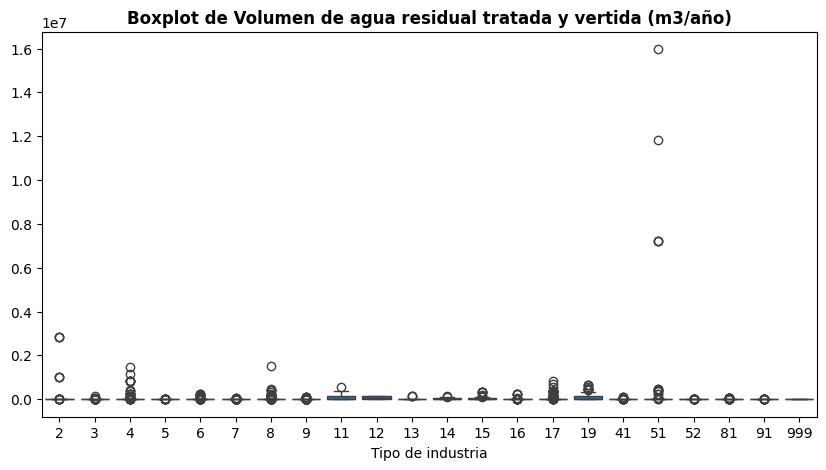

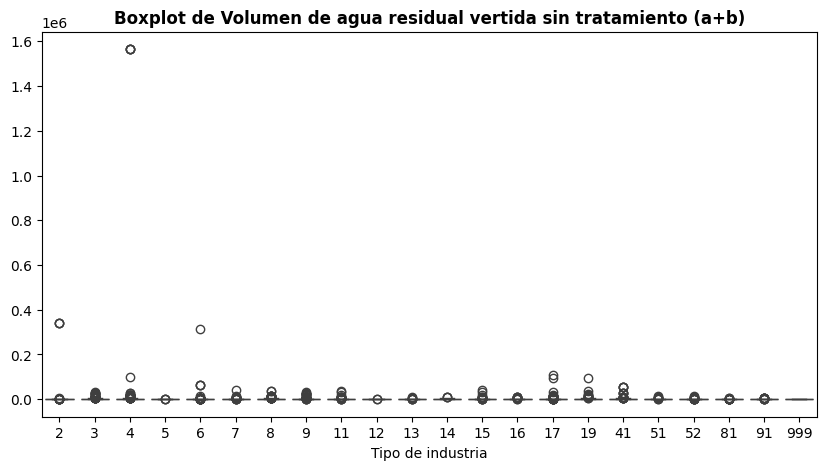

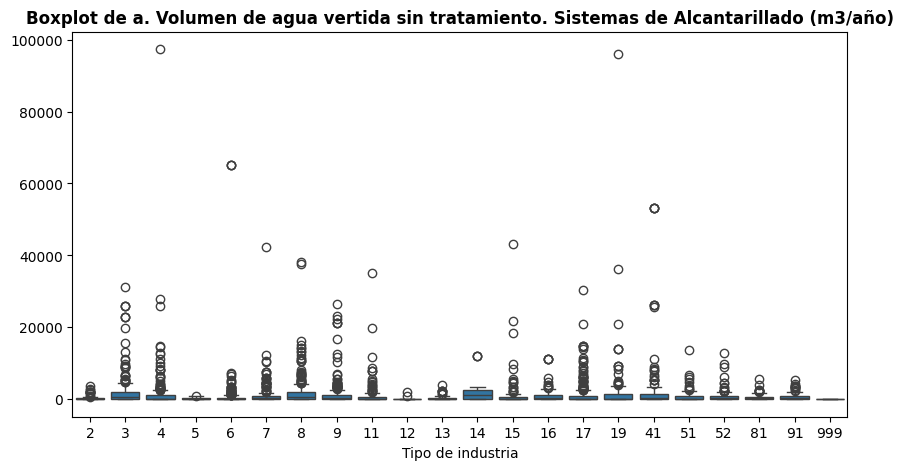

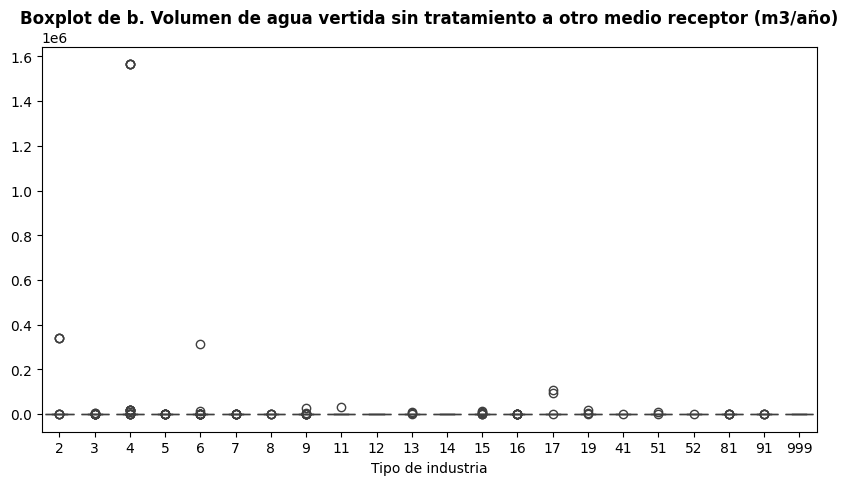

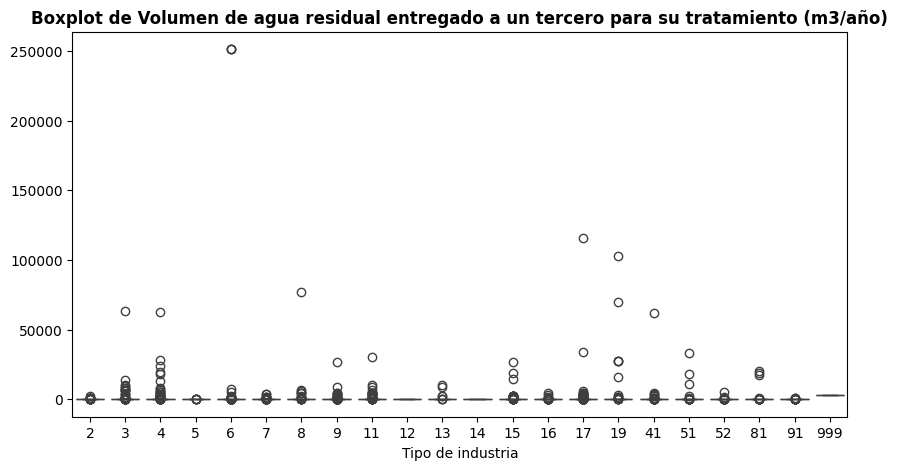

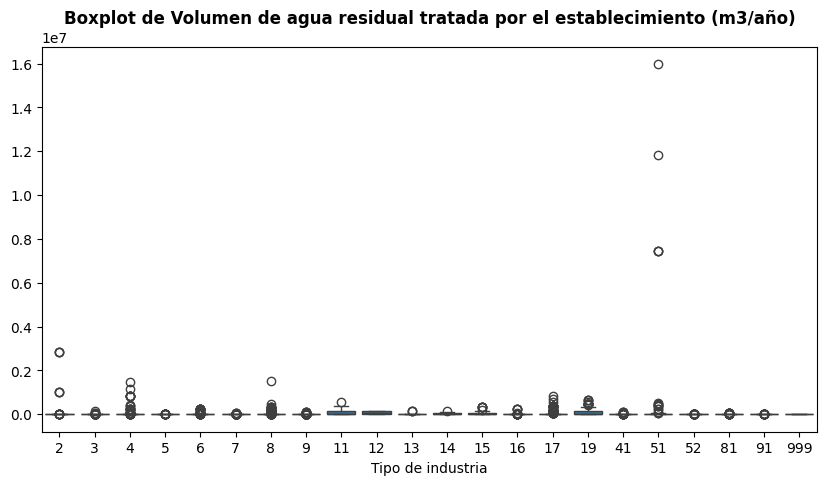

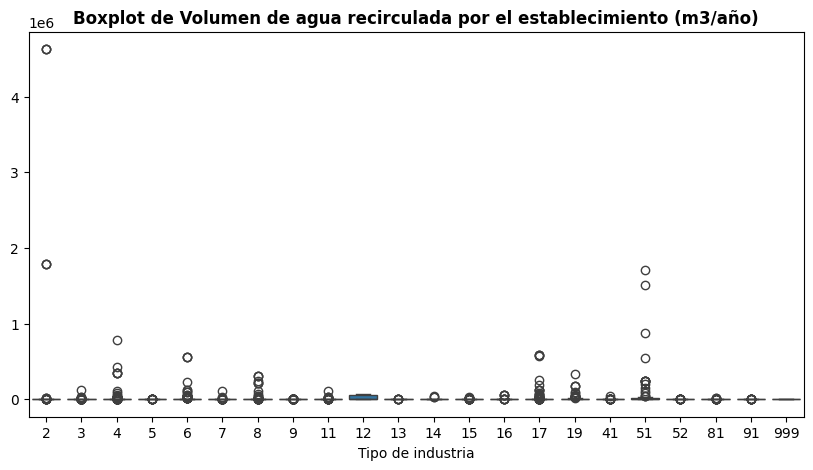

In [24]:
#Visualización de valores atipicos por cada variable
for col in variables_numericas:
  plt.figure(figsize=(10,5))
  sns.boxplot(y=df[col],x=df["CODIGO_ACTIVIDAD"])
  plt.title(f"Boxplot de {col}",fontweight="bold")
  plt.xlabel("Tipo de industria")
  plt.ylabel("")
  plt.show()

Vemos que la **Actividad Industrial No. 51**, correspondiente a la "**Fabricación de papel, cartón y productos de papel y cartón"** presenta valores significativos en los volumenes de agua presentes en las variables de estudio. Esto puede inferirse a una industria bastante grande. Esto puede tener sentido teniendo en cuenta el consumo de agua necesario para la fabricación de papel y cartón.

**Otras actividades industriales remarcardas con valores llamativos:**
*   2 Coquización, fabricación de productos de la refinación del petróleo y actividad de mezcla de combustibles
*   4 Fabricación de productos y sustancias químicas
*   6 Fabricación de otros productos minerales no metálicos
*   8 Fabricación de productos textiles y confección de prendas de vestir
*   17 Otros productos elaborados de alimentos
*   19 Bebidas y tabaco

Por lo cual, con el objetivo de no sesgar los datos se optará por mantener los registros y realizar escalamiento posteriormente.

### ***2.4 Correlación entre variables (Mapa de calor):***

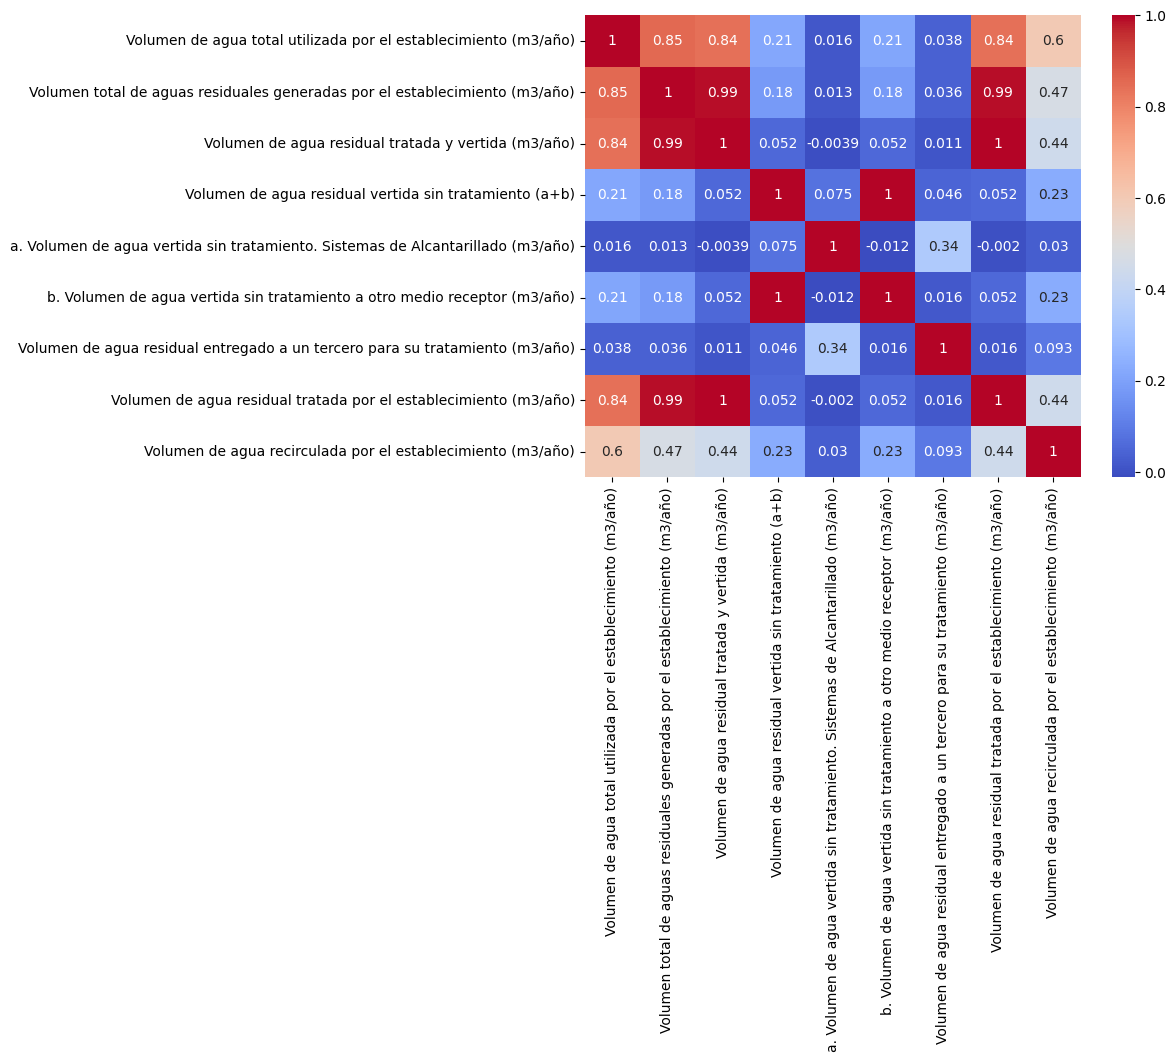

In [25]:
plt.figure(figsize=(8,6))
sns.heatmap(df[variables_numericas].corr(),cmap="coolwarm",annot=True)
plt.show()

El mapa de correlación permite identificar:
* Una correlación fuerte y positiva entre el volumen de agua tratada por el establecimiento y el volumen de agua tratada y vertida (1)
* Una correlación fuerte y positiva entre el volumen de agua sin tratar y el volumen de agua vertida sin tratamiento a otros medios receptores (1)
* Una correlación fuerte y positiva entre el volumen de agua residual generada y el volumen de agua residual tratada y vertida (0.99).
* Una correlación fuerte y positiva entre el volumen de agua residual generada por el establecimiento y el volumen de agua tratada por el establecimiento (0.99)
*   Una correlación fuerte y positiva entre el volumen de agua utilizada por el establecimiento y el volumen de agua residual generada (0.86)
*   Una correlación fuerte y positiva entre el  volumen de agua utilizada por el establecimiento y el volumen de agua tratada y vertida (0.84)
* Una correlación fuerte entre el volumen de agua utilizada por el establecimiento y el volumen de agua tratada por el establecimiento (0.84)
* Una correlación moderada y positiva entre el volumen de agua tratada por el establecimiento y el volumen de agua recirculada (0.47)
*  Una correlación moderada y positiva entre el volumen de agua tratada y vertida y el volumen de agua recirculada.

Estas correlaciones permiten evidenciar:
* La gran mayoria de las industrias encuestadas presentan sus propios mecanismos para tratar el agua residual, casi la mitad de las industrias recirculan el agua tratada y cerca de la otra mitad la vierte. Esta caracterización puede ser clave en la generación de clusters.



## **Paso 3: Reporte de la calidad de los datos y tratamiento:**

### ***3.1 Identificación de posibles registros duplicados***

In [26]:
df.duplicated().sum()

np.int64(0)

Se identifica que la base de datos no presenta registros duplicados.

### ***3.2 Porcentaje de faltantes***

In [27]:
100*(df.isnull().sum()/df.isnull().count())

,0
CODIGO_REGISTRO,0.0
CODIGO_ACTIVIDAD,0.0
CODIGO_REGION,0.0
Volumen de agua total utilizada por el establecimiento (m3/año),0.0
Volumen total de aguas residuales generadas por el establecimiento (m3/año),0.0
Volumen de agua residual tratada y vertida (m3/año),0.0
Volumen de agua residual vertida sin tratamiento (a+b),0.0
a. Volumen de agua vertida sin tratamiento. Sistemas de Alcantarillado (m3/año),0.0
b. Volumen de agua vertida sin tratamiento a otro medio receptor (m3/año),0.0
Volumen de agua residual entregado a un tercero para su tratamiento (m3/año),0.0


Se confirma que la base de datos no presenta registros nulos.

## **Paso 4: Escalamiento de variables:**

Teniendo en cuenta que las variables presentan diferentes tamaños, resulta fundamental aplicar una técnica de escalamiento que permita comparar las variables para poderlas ingresar al modelo.
* No se puede utilizar normalización min-max debido a la presencia de datos atipicos fuertes, lo cual afecta de manera significativa el método de Min - Max.
* Si utilizamos el escalamiento robusto observamos que las escalas de las diferentes variables difieren en gran medida por lo cual no es el método más óptimo para hacer las variables comparables.
* Al utilizar el escalamiento estandar (Z-score) se observa mediante los histogramas que es el método que permite que las variables presenten escalas comparables.


In [28]:
from sklearn.preprocessing import StandardScaler

df_scaled = pd.DataFrame(StandardScaler().fit_transform(df[variables_numericas]), columns=df[variables_numericas].columns)

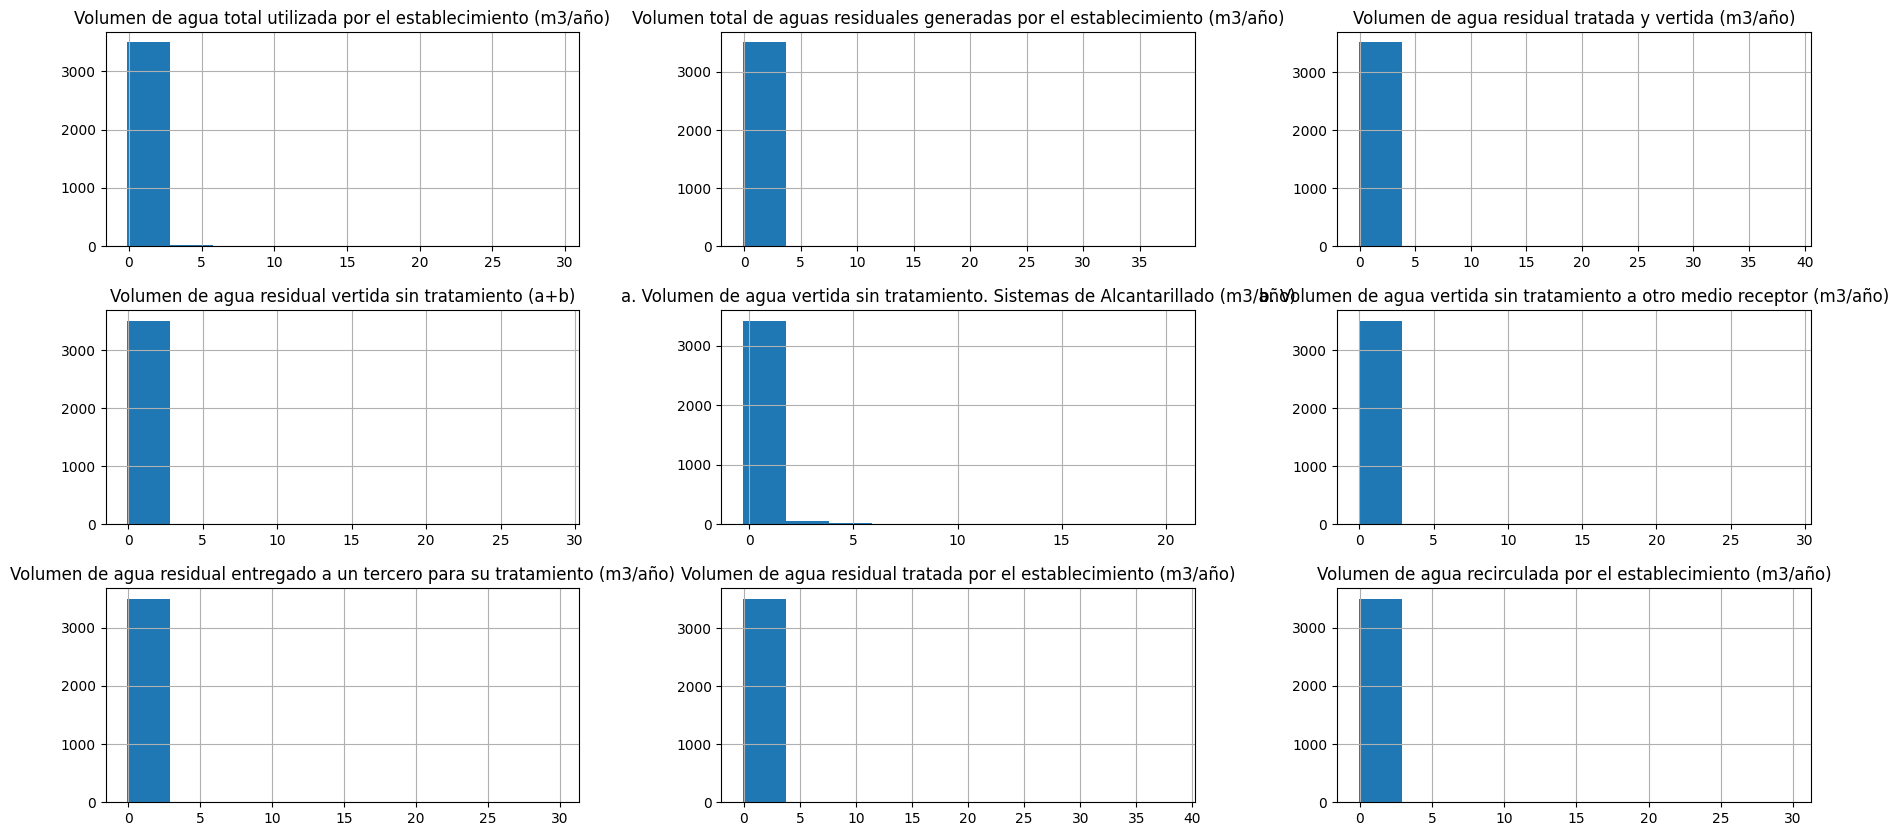

In [29]:
#Histograma de datos escalados:
df_scaled.hist(figsize=(22,10))
plt.show()

## **Paso 5: Reducción de dimensionalidad por Análisis de componentes principales:**

La base de datos contiene cerca de 9 variables de análisis, por lo cual se busca aplicar Análsis de componentes principales para reducir su dimensionalidad.

In [30]:
from sklearn.decomposition import PCA

modelo_pca=PCA() #Creo el objeto con el modelo que aprendera los datos y que contiene los atributos y funciones de interés
df_pca=modelo_pca.fit_transform(df_scaled) #Entreno el modelo con los datos y transformo los datos en los componentes principales
df_pca=pd.DataFrame(df_pca,columns=["PCA1","PCA2","PCA3","PCA4","PCA5","PCA6","PC7","PC8","PC9"])

#Varianza explicada de cada componente principal

varianza=pd.DataFrame({
    "Componente":df_pca.columns,
    "Eigenvalue":modelo_pca.explained_variance_,
    "% Varianza explicada por componente":modelo_pca.explained_variance_ratio_,
    "% Varianza explicada acumulada":modelo_pca.explained_variance_ratio_.cumsum()})
varianza

,Componente,Eigenvalue,% Varianza explicada por componente,% Varianza explicada acumulada
0,PCA1,4.160890e+00,4.621898e-01,0.462190
1,PCA2,1.977787e+00,2.196917e-01,0.681881
2,PCA3,1.342602e+00,1.491356e-01,0.831017
3,PCA4,7.123233e-01,7.912454e-02,0.910142
4,PCA5,6.369684e-01,7.075415e-02,0.980896
5,PCA6,1.715720e-01,1.905814e-02,0.999954
6,PC7,4.156129e-04,4.616609e-05,1.000000
7,PC8,3.422160e-13,3.801320e-14,1.000000
8,PC9,3.894002e-14,4.325440e-15,1.000000


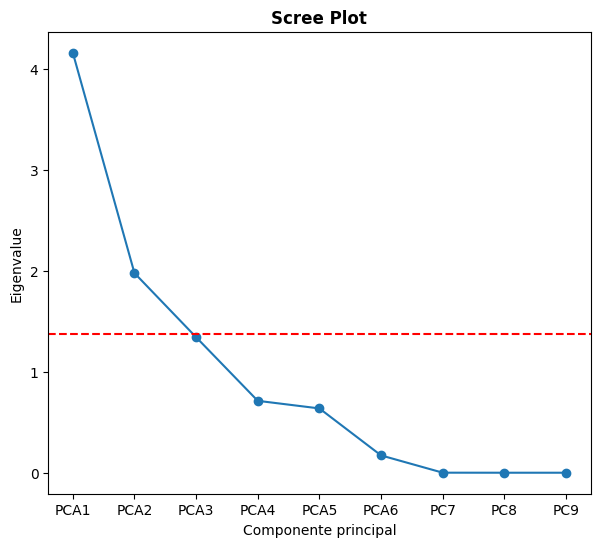

In [31]:
plt.figure(figsize=(7,6))
plt.plot("Componente","Eigenvalue",data=varianza,marker="o")
plt.axhline(y=1.37,color="red",linestyle="--")
plt.title("Scree Plot", fontweight="bold")
plt.ylabel("Eigenvalue")
plt.xlabel("Componente principal")
plt.show()

Mediante el Scree Plot es posible identificar que los dos primeros componentes principales explican el 68% de la varianza acumulada, y el tercer componente explica  el 83% de la varianza acumulada.


La varianza será importante considerarla al momento de realizar las gráficas en 2D  entendiendo que la varianza explicada por los datos de los dos primeros componentes.

In [32]:
#Análisis de cargas
loadings = pd.DataFrame(
    modelo_pca.components_.T,
    columns=df_pca.columns,
    index=df_scaled.columns
)
loadings

,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PC7,PC8,PC9
Volumen de agua total utilizada por el establecimiento (m3/año),0.453719,-0.028003,-0.002812,0.081569,-0.072444,0.883993,-0.000751,1.106759e-10,5.815029e-09
Volumen total de aguas residuales generadas por el establecimiento (m3/año),0.476271,-0.089891,-0.013193,-0.179140,0.118183,-0.221470,-0.405214,-5.226162e-02,7.091365e-01
Volumen de agua residual tratada y vertida (m3/año),0.464762,-0.181210,-0.020763,-0.171850,0.101331,-0.220542,-0.415110,5.144749e-02,-6.980875e-01
Volumen de agua residual vertida sin tratamiento (a+b),0.140880,0.674894,-0.052594,-0.127794,0.045026,-0.035593,0.026034,-7.014577e-01,-9.776866e-02
a. Volumen de agua vertida sin tratamiento. Sistemas de Alcantarillado (m3/año),0.012043,0.070383,0.698511,-0.435970,-0.559511,-0.007351,0.002363,6.165991e-02,5.410282e-04
b. Volumen de agua vertida sin tratamiento a otro medio receptor (m3/año),0.140221,0.670626,-0.113726,-0.090086,0.094001,-0.035050,0.025900,7.062407e-01,6.196762e-03
Volumen de agua residual entregado a un tercero para su tratamiento (m3/año),0.028021,0.067985,0.700788,0.326050,0.629947,0.011543,0.003320,1.046837e-03,-1.420447e-02
Volumen de agua residual tratada por el establecimiento (m3/año),0.464628,-0.180973,-0.016954,-0.172250,0.106600,-0.218941,0.813703,-1.363267e-07,-1.139941e-07
Volumen de agua recirculada por el establecimiento (m3/año),0.308193,0.103684,0.066173,0.762383,-0.488266,-0.265048,0.002496,2.199048e-09,-3.426004e-08


## **Paso 6: Clusterizacion:**

### ***6.1 K-Means:***

#### ***6.1.1 Determinación del número de clusters recomendados por el método del Elbow con todas las variables escaladas (df_scaled):***

K-means es un algoritmo de agrupamiento iterativo basado en centroides, el cual, divide un conjunto de datos en grupos similares en función de la distancia entre sus centroides. K-means es un proceso iterativo en el que busca minimizar la suma de distancias entre los puntos de datos y sus centroides de clúster. Este método utiliza internamente para sus calculos la métrica de distancia euclidiana.

Para recordar, kmeans funciona de la siguiente manera:
 1. El algoritmo genera centroides al azar
 2. El algoritmo asigna cada punto del conjunto de datos al cluster cuyo centroide esté más cerca. Para hacer esto, se calcula la distancia entre cada punto y cada centroide y se asigna el punto al cluster cuyo centroide tenga la menor distancia.
 3. El algoritmo recalcula los centroides de cada cluster como la media de todos los puntos del cluster. De esta manera se actualiza la posición del centroide.
 4.  Se repite los pasos 2 y 3 hasta que los centroides de los clusters ya no cambien o hasta que se alcance el número máximo de iteraciones.

Ahora bien, antes de aplicar el cluster por k-means, se utilizó el método del codo (una evaluación itertiva por k-means) para generan interaciones de k-clusters en el rango (2 a 10) y se calcula la inercia (la suma de los cuadrados de las distancias de cada punto al centroide). Donde se empieza a estabilizar, es donde se escoge el número de clusters para usar dentro de k-means.

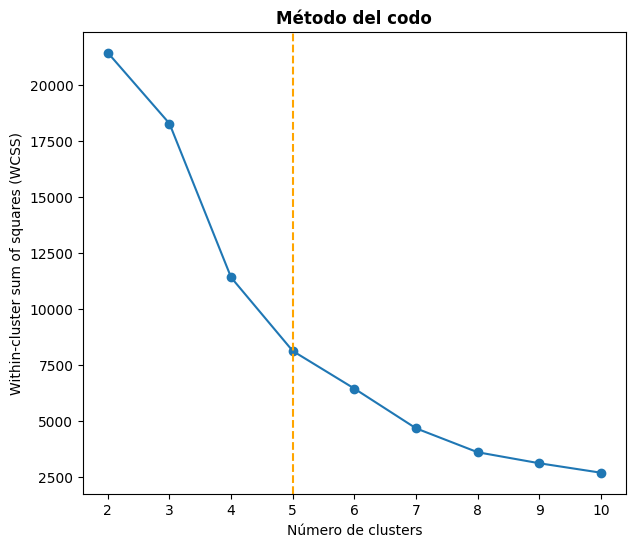

In [33]:
from sklearn.cluster import KMeans

wcss=[] # Within-cluster sum of squares: Siglas de suma de las distancias elevada al cuadrado entre cada punto y su centroide
for k in range (2,11):
  codo_kmeans=KMeans(n_clusters=k, init="k-means++" , max_iter=300, random_state=0) #Pruebo k número de cluster, con el método K-means++, máximo de veces que repite el ciclo iteracioens =300
  codo_kmeans.fit(df_scaled) #Entreno el modelo con mis datos escalados, inicializo (ubico centroides), asigno puntos a clusters, recalculo centroides, y repito el proceso
  wcss.append(codo_kmeans.inertia_) #.inertia_ devuelve la suma de los cuadrados de las distancias de cada punto al centroide

plt.figure(figsize=(7,6))
plt.plot(range(2,11),wcss, marker="o") #Creación del grafico de lineas
plt.title("Método del codo",fontweight="bold")
plt.xlabel("Número de clusters")
plt.ylabel("Within-cluster sum of squares (WCSS)")
plt.axvline(x=5, color="orange",linestyle="--")
plt.show()


Mediante el método de elbow se sugiere utilizar un número de clusters = 5.

In [34]:
#help(KMeans)

#### ***6.1.2 Clusterización con k-means:***

In [35]:
#Creo una copia de la base de datos analizadas donde ire guardando las etiquetas (labels) de cada cluster para no afectar los modelos al entrenarlos
df_scaled_clusters=df_scaled.copy()

In [36]:
#Clusterización KMeans
kmeans=KMeans(n_clusters=5,init="k-means++",max_iter=300,random_state=0) #Creo el modelo con los parámetros definidos para el funcionamiento del algoritmo
labels_kmeans=kmeans.fit_predict(df_scaled) #Entreno el modelo con los datos para que asigne cada observación a un cluster
df_scaled_clusters["Cluster KMeans"]=labels_kmeans #Creo una columna en el data frame original que guarde el cluster al que pertenece cada registro por kmeans
kmeans.cluster_centers_  #Visualización de los centroides por cada variable de los 4 clusters. #Como los datos ya estaban escalados, los centroides también se calculan escalados

array([[-5.47577126e-02, -4.82116763e-02, -4.33114325e-02,
        -3.91464558e-02, -1.05733605e-02, -3.83322046e-02,
        -2.60090769e-02, -4.35414391e-02, -4.79290969e-02],
       [ 2.56564353e+01,  3.30559932e+01,  3.35898031e+01,
        -6.86597277e-02, -2.96474918e-01, -4.29663321e-02,
        -7.93727381e-02,  3.33307992e+01,  1.02895880e+01],
       [ 1.20214161e+01,  8.27158240e+00,  8.16237246e+00,
         1.83667958e+00, -1.84438093e-01,  1.85789075e+00,
        -3.70687518e-02,  8.24719098e+00,  1.27984765e+01],
       [ 4.23112149e+00,  4.18024873e+00,  4.53174338e-01,
         2.88435520e+01, -2.96474918e-01,  2.89496600e+01,
         5.10405811e-01,  4.57913077e-01,  2.12837844e+00],
       [ 1.06682539e+00,  1.06402055e+00,  3.24661902e-01,
         1.13630371e+00,  1.35433307e+01, -4.29663321e-02,
         2.98398596e+01,  4.76625424e-01,  3.55812825e+00]])



> ###### ***6.1.2.1 Visualización K-Means en espacio PCA:***


In [37]:
centroides_pca = modelo_pca.transform(kmeans.cluster_centers_) #Transformo los centroides proyectandolos al espacio donde se encuentran los PCA calculados con base en los datos escalados
centroides_pca  #Se observan en dos dimensiones y por lo cual los podemos graficar mediante diagrama de dispersion con los componentes 1 y 2

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


array([[-1.14683972e-01, -3.80127943e-02, -1.99383072e-02,
        -1.28418745e-02, -3.19341906e-03, -3.42517104e-03,
        -1.16534680e-04, -1.19762731e-10,  1.40820338e-09],
       [ 6.16317985e+01, -1.48431829e+01, -1.34409410e+00,
        -7.38188574e+00,  4.08946966e+00, -2.06824000e+00,
        -2.14298912e-01,  8.98000235e-08, -2.09772600e-07],
       [ 2.14797018e+01, -2.54773674e-01, -6.80174168e-02,
         6.09910043e+00, -4.09893878e+00,  1.66738510e+00,
         8.90126178e-02,  7.19252144e-09, -3.95847203e-07],
       [ 1.31235514e+01,  3.84560126e+01, -4.60210864e+00,
        -4.93614708e+00,  3.75044779e+00,  1.69395439e-02,
        -5.57208382e-03,  8.64972002e-09, -1.18000591e-07],
       [ 3.61302780e+00,  3.81827747e+00,  3.05202907e+01,
         6.15463870e+00,  9.66187468e+00, -2.05676848e-01,
        -1.04562123e-02,  4.43486851e-08, -2.62321915e-08]])

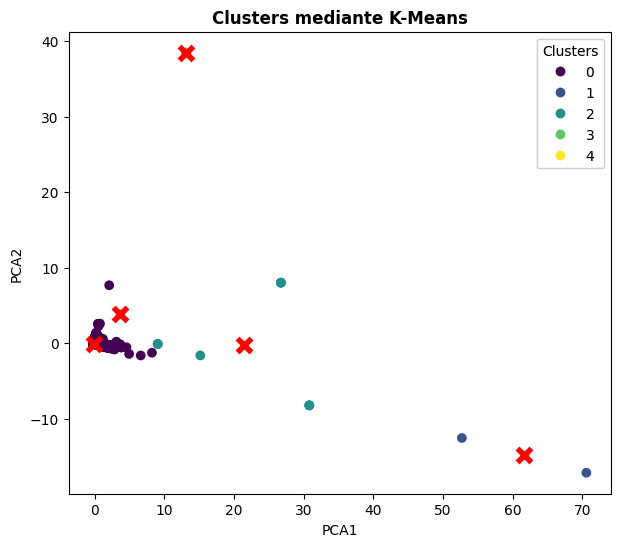

In [38]:
#Visualización de los clusters utilizando los dos primeros componentes principales
plt.figure(figsize=(7,6))
scatter=plt.scatter(x=df_pca.iloc[:,0],y=df_pca.iloc[:,1],c=df_scaled_clusters["Cluster KMeans"])
plt.scatter(x=centroides_pca[:,0], y=centroides_pca[:,1],marker="x",s=100,linewidths=4,color="red")
plt.title("Clusters mediante K-Means", fontweight="bold")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
legend = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend)
plt.show()

In [39]:
pd.Series(labels_kmeans).value_counts().sort_index()

,count
0,3500
1,2
2,10
3,4
4,3


Dado que los outliers están sesgando la generación de clusters, se realiza un filtro de los mismos para verificar cambios la creación de clusters.
El filtro consistira en quedarnos con los datos presentes entre el percentil del 1% y el percentil del 99%.



> ###### ***6.1.2.2 Visualización K-Means en espacio PCA Sin Outliers:***


In [40]:
variables_numericas

['Volumen de agua total utilizada por el establecimiento (m3/año)',
 'Volumen total de aguas residuales generadas por el establecimiento (m3/año)',
 'Volumen de agua residual tratada y vertida (m3/año)',
 'Volumen de agua residual vertida sin tratamiento (a+b)',
 'a. Volumen de agua vertida sin tratamiento. Sistemas de Alcantarillado (m3/año)',
 'b. Volumen de agua vertida sin tratamiento a otro medio receptor (m3/año)',
 'Volumen de agua residual entregado a un tercero para su tratamiento (m3/año)',
 'Volumen de agua residual tratada por el establecimiento (m3/año)',
 'Volumen de agua recirculada por el establecimiento (m3/año)']

In [41]:
#Se retiran los outliers con valores inferior al quantil (percentil) del 1% o superior al percentil del 99% en los datos originales
df_numerico=df[variables_numericas]
Q001=df_numerico.quantile(0.01)
Q99=df_numerico.quantile(0.99)

df_filtrado=df_numerico[((df_numerico>=Q001) & (df_numerico<=Q99)).all(axis=1)].copy()
print("Datos originales:",df_numerico.shape)
print("Datos filtrados:",df_filtrado.shape)


Datos originales: (3519, 9)
Datos filtrados: (3371, 9)


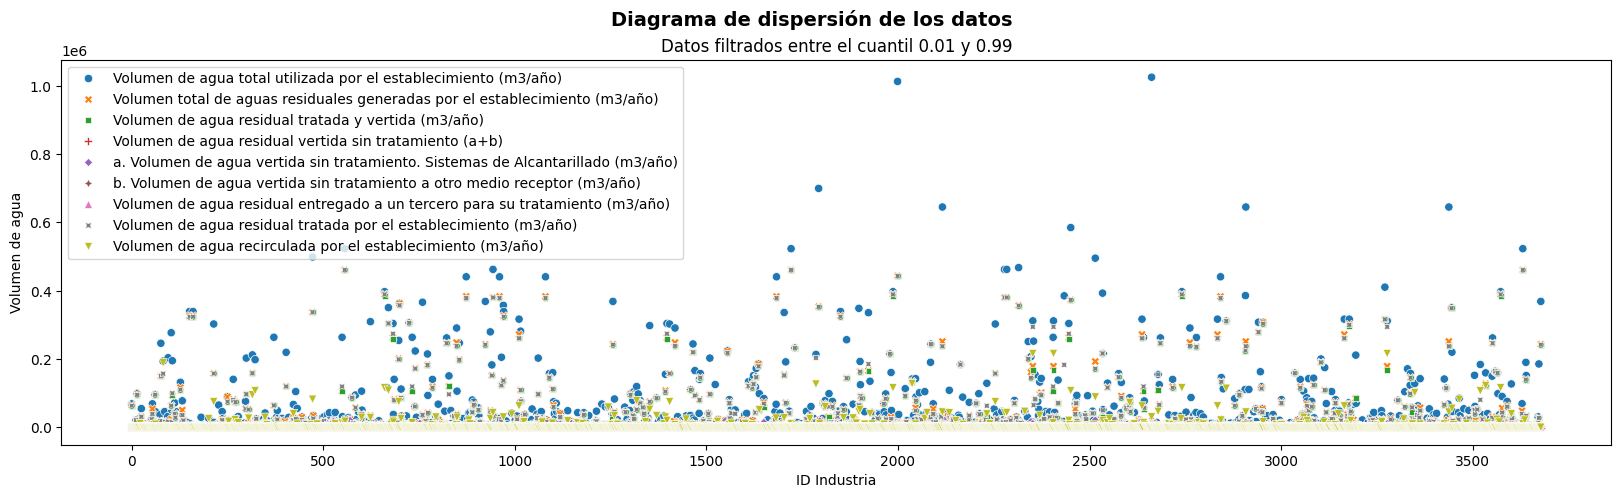

In [42]:
#Visualización de la base de datos filtrada entre el percentil del 1% y el 99%
plt.figure(figsize=(20,5))
sns.scatterplot(df_filtrado)
plt.suptitle("Diagrama de dispersión de los datos", fontweight="bold",fontsize=14)
plt.title("Datos filtrados entre el cuantil 0.01 y 0.99", fontsize=12)
plt.xlabel("ID Industria")
plt.ylabel("Volumen de agua")
plt.show()

In [43]:
#Escalamiento de datos filtrados
df_scaled_filtrado = pd.DataFrame(StandardScaler().fit_transform(df_filtrado), columns=df_filtrado.columns)

In [44]:
#Genero nuevos compomentes principales a la base de datos filtrada sin outliers
modelo_pca_filtrado=PCA(n_components=2) #Genero un nuevo modelo para ser usado con los datos filtrados
df_pca_filtrado=modelo_pca_filtrado.fit_transform(df_scaled_filtrado) #Entrene el nuevo modelo
df_pca_filtrado=pd.DataFrame(df_pca_filtrado,columns=["PCA1","PCA2"])



In [45]:
#Cargas para los PCA de la base filtrada sin outliers
loadings_pca_filtrado = pd.DataFrame(
    modelo_pca_filtrado.components_.T,
    columns=df_pca_filtrado.columns,
    index=df_scaled_filtrado.columns)
loadings_pca_filtrado

,PCA1,PCA2
Volumen de agua total utilizada por el establecimiento (m3/año),0.456129,-0.046492
Volumen total de aguas residuales generadas por el establecimiento (m3/año),0.478101,-0.064166
Volumen de agua residual tratada y vertida (m3/año),0.475235,-0.095314
Volumen de agua residual vertida sin tratamiento (a+b),0.098945,0.694269
a. Volumen de agua vertida sin tratamiento. Sistemas de Alcantarillado (m3/año),0.100026,0.694366
b. Volumen de agua vertida sin tratamiento a otro medio receptor (m3/año),-0.019629,-0.011978
Volumen de agua residual entregado a un tercero para su tratamiento (m3/año),0.110838,-0.101494
Volumen de agua residual tratada por el establecimiento (m3/año),0.480514,-0.088719
Volumen de agua recirculada por el establecimiento (m3/año),0.272321,0.046546


In [46]:
pc1_loadings = loadings_pca_filtrado.iloc[:, 0].sort_values()
pc2_loadings = loadings_pca_filtrado.iloc[:, 1].sort_values()

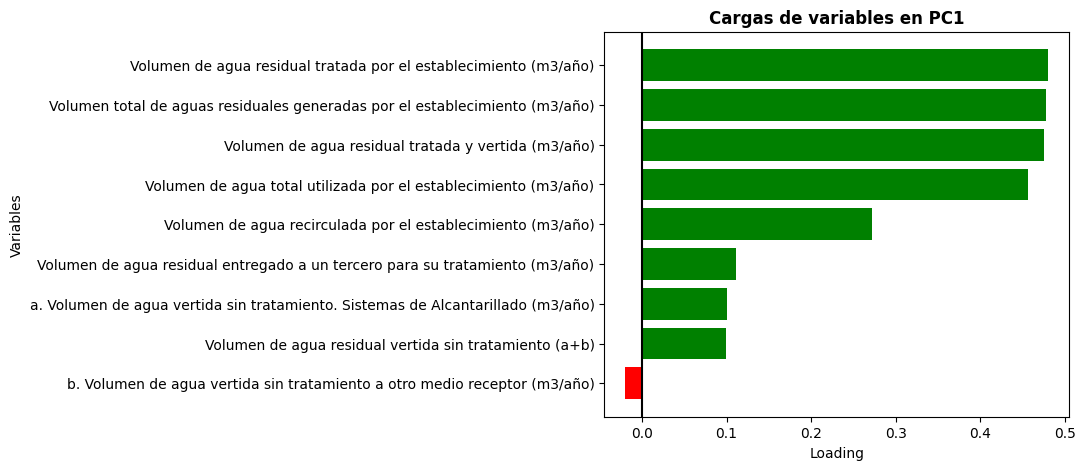

In [47]:
#Generamos un gráfico de cargas de PCA1 de la base filtrada para posteriormente analizarla
colors = np.where(pc1_loadings >= 0, "green", "red")

plt.figure(figsize=(6,5))
plt.barh(pc1_loadings.index, pc1_loadings.values, color=colors)

plt.axvline(0, color="black")
plt.title("Cargas de variables en PC1",fontweight="bold")
plt.xlabel("Loading")
plt.ylabel("Variables")
plt.show()

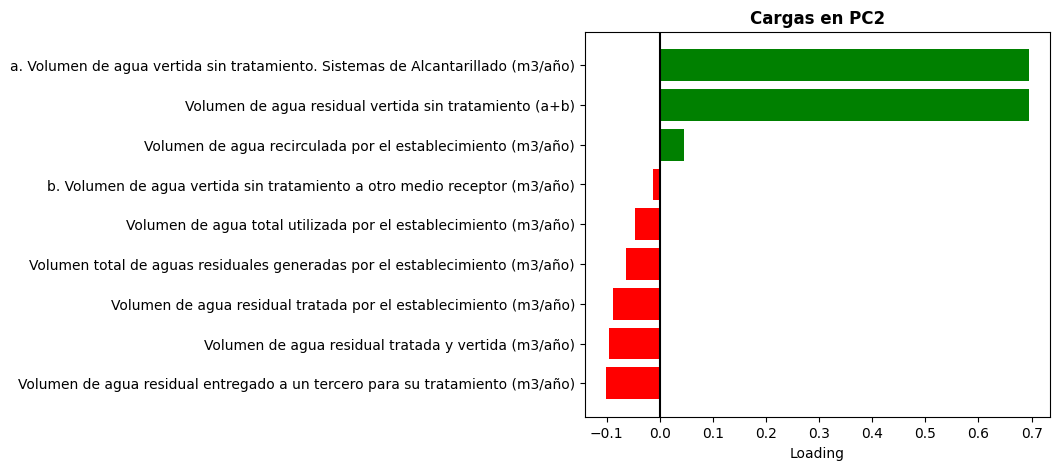

In [48]:
#Generamos un gráfico de cargas de PCA2 de la base filtrada para posteriormente analizarla
colors = np.where(pc2_loadings >= 0, "green", "red")

plt.figure(figsize=(6,5))
plt.barh(pc2_loadings.index, pc2_loadings.values, color=colors)

plt.axvline(0, color="black")
plt.title("Cargas en PC2",fontweight="bold")
plt.xlabel("Loading")
plt.show()

In [49]:
#Creo una copia de la base de datos analizada Y FILTRADA donde ire guardando las etiquetas (labels) de cada cluster para no afectar los modelos al entrenarlos
df_scaled_filtrado_clusters=df_scaled_filtrado.copy()

In [50]:
#Creación clusters con Kmeans sin outliers
kmeans_sin_outliers=KMeans(n_clusters=5,init="k-means++",max_iter=300,random_state=0)
labels_kmeans_sin_outliers=kmeans_sin_outliers.fit_predict(df_scaled_filtrado)
df_scaled_filtrado_clusters["Cluster Kmeans sin outliers"]=labels_kmeans_sin_outliers
pd.Series(labels_kmeans_sin_outliers).value_counts()

# Conversión de los centroides al espacio de PCA usando los mismo componentes, rotaciones y espacio con el que se entreno el modelo anteriormente
centroides_pca = modelo_pca_filtrado.transform(kmeans_sin_outliers.cluster_centers_)
centroides_pca

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


array([[ 0.67807496,  4.58402334],
       [10.60285915, -0.77313214],
       [-0.35976123, -0.21289437],
       [-0.77105004, -0.27714184],
       [ 0.46718956, -1.1603951 ]])

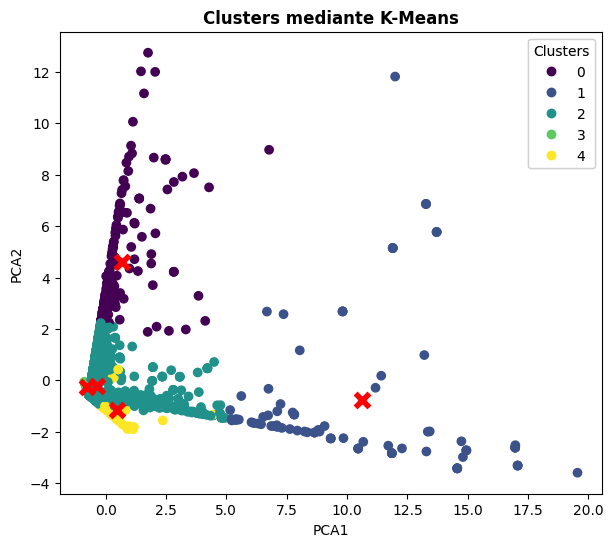

In [51]:
#Visualización de los clusters utilizando los dos primeros componentes principales
plt.figure(figsize=(7,6))
scatter=plt.scatter(x=df_pca_filtrado.iloc[:,0],y=df_pca_filtrado.iloc[:,1],c=df_scaled_filtrado_clusters["Cluster Kmeans sin outliers"])
plt.scatter(x=centroides_pca[:,0], y=centroides_pca[:,1],marker="x",s=100,linewidths=4,color="red")
plt.title("Clusters mediante K-Means", fontweight="bold")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
legend = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend)
plt.show()

In [52]:
pd.Series(labels_kmeans_sin_outliers).value_counts().sort_index()

,count
0,170
1,92
2,3035
3,27
4,47


Con KMeans se generan los 5 clusters,sin embargo, se evidencia que existe cierta heterogeneidad y dispersión dentro de algunos clusters. Así mismo, puede existir cierta superposición de los mismos.

### ***6.2 Clustering Jerárquico***

El clustering jerarquico agrupa los datos similares construyendo una jerarquía de clústeres. En el presente proyecto se manejó el cluster jerarquico aglomerativo el cual funciona de la siguiente manera:
1. Inicia tomando cada punto como un cluster independiente
2. Calcula la distancia entrre todos los clusters.
3. Se unen los clusters más cercanos.
4. Se recalculan las distancias entre los nuevos clusters.
5. Se repite los pasos 2 a 4 hasta formar solo un grupo


#### ***6.2.1 Clusterización Jerarquica con outliers***

> ##### ***6.2.1.1 Dendograma clusterización Jerarquica con outliers:***

In [53]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
linked = linkage(df_scaled, method='complete',metric="euclidean")

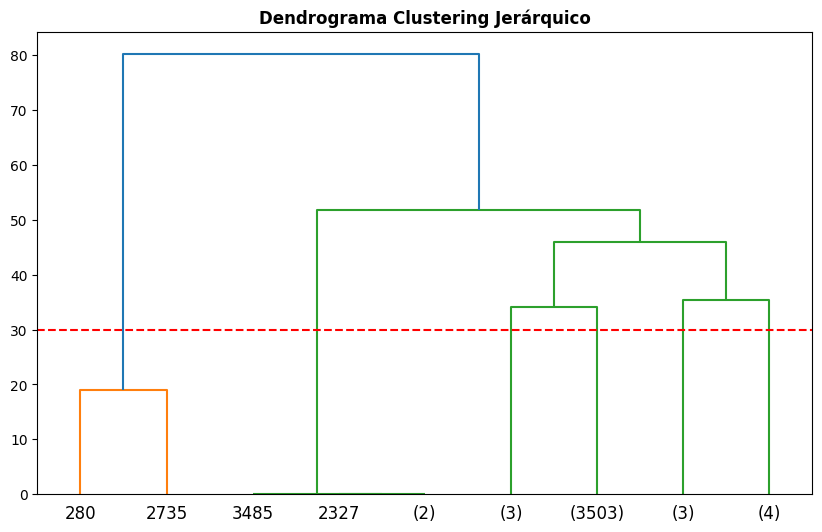

In [54]:
plt.figure(figsize=(10,6))
dendrogram(linked, truncate_mode='level', p=3) #truncate_modo simplifica mostrando solo los niveles superiores
plt.title("Dendrograma Clustering Jerárquico",fontweight="bold")
plt.axhline(y=30,color="red",linestyle="--")
plt.show()

> ##### ***6.2.1.2 Clusterización Jerarquica con outliers:***

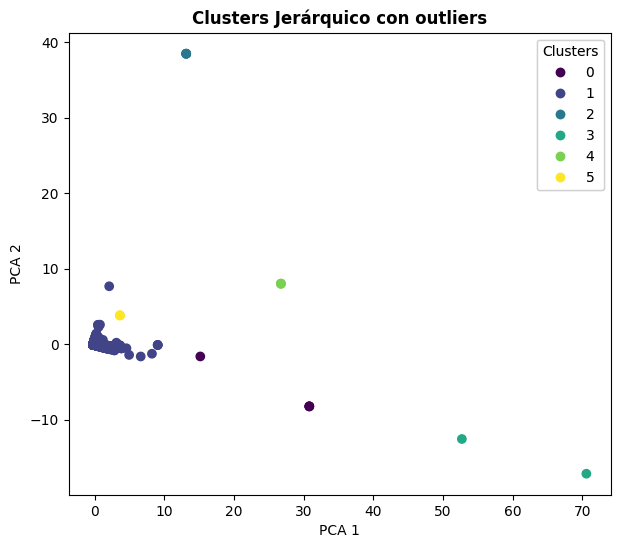

In [55]:
from sklearn.cluster import AgglomerativeClustering

jerarquico = AgglomerativeClustering(n_clusters=6, linkage="complete",metric="euclidean")
labels_jerarquico_con_outliers=jerarquico.fit_predict(df_scaled)
df_scaled_clusters["Cluster Jerarquico con outliers"] = labels_jerarquico_con_outliers

# Visualización
plt.figure(figsize=(7,6))
scatter=plt.scatter(df_pca.iloc[:,0], df_pca.iloc[:,1], c=df_scaled_clusters["Cluster Jerarquico con outliers"])
plt.title("Clusters Jerárquico con outliers",fontweight="bold")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
legend = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend)
plt.show()

In [56]:
pd.Series(labels_jerarquico_con_outliers).value_counts().sort_index()

,count
0,4
1,3503
2,4
3,2
4,3
5,3


#### ***6.2.2 Clusterización Jerarquica sin outliers***

> ##### ***6.2.2.1 Dendograma clusterización Jerarquica sin outliers:***


In [57]:
linked = linkage(df_scaled_filtrado, method='complete', metric="euclidean")#Tomo los datos escalados y calcula la distancia entre puntos. Con el método ward busca disminuir la varianza interna del cluster

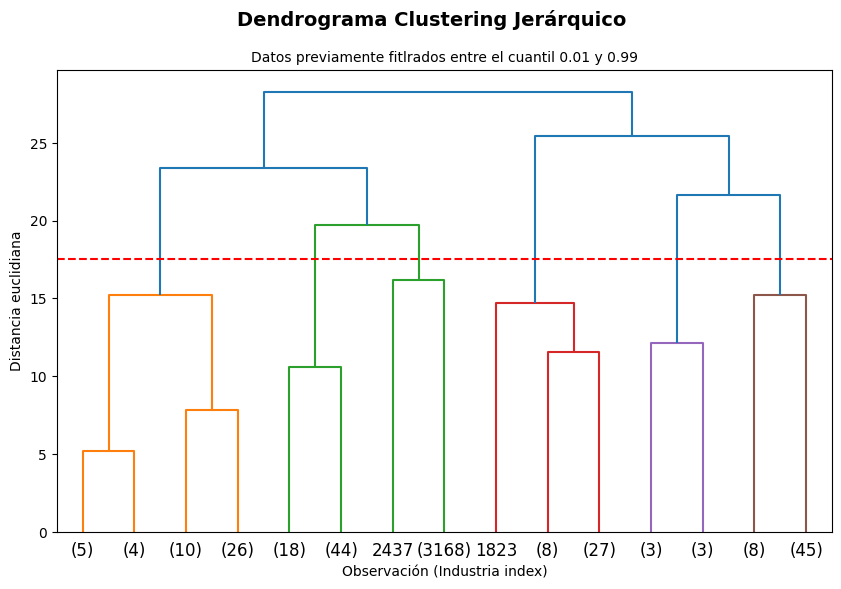

In [58]:
plt.figure(figsize=(10,6))
dendrogram(linked, truncate_mode='level', p=3) #truncate_modo simprifica mostrando solo los niveles supereiroe
plt.suptitle("Dendrograma Clustering Jerárquico",fontweight="bold",fontsize=14)
plt.title("Datos previamente fitlrados entre el cuantil 0.01 y 0.99",fontsize=10)
plt.xlabel("Observación (Industria index)")
plt.ylabel("Distancia euclidiana")
plt.axhline(y=17.5,color="red",linestyle="--")
plt.show()

> ##### ***6.2.2.2 clusterización Jerarquica sin outliers:***

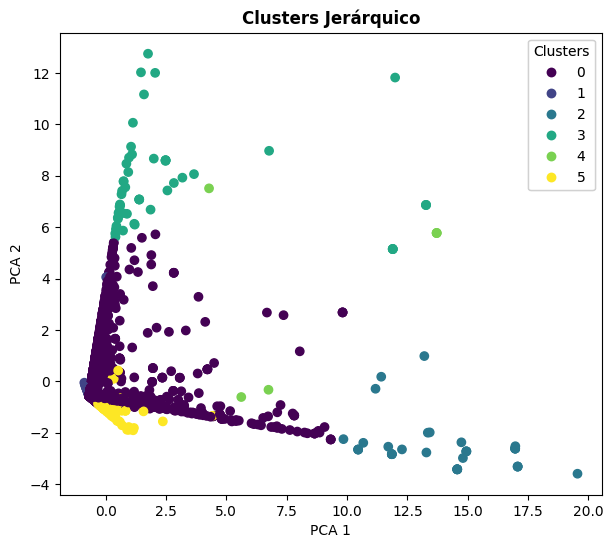

In [59]:
jerarquico_filtrado = AgglomerativeClustering(n_clusters=6, linkage="complete",metric="euclidean")
labels_jerarquico_sin_outliers=jerarquico_filtrado.fit_predict(df_scaled_filtrado)
df_scaled_filtrado_clusters["Cluster Jerarquico sin outliers"] = labels_jerarquico_sin_outliers

# Visualización
plt.figure(figsize=(7,6))
scatter=plt.scatter(x=df_pca_filtrado.iloc[:,0], y=df_pca_filtrado.iloc[:,1], c=df_scaled_filtrado_clusters["Cluster Jerarquico sin outliers"])
plt.title("Clusters Jerárquico",fontweight="bold")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
legend = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend)
plt.show()

In [60]:
pd.Series(labels_jerarquico_sin_outliers).value_counts().sort_index()

,count
0,3169
1,45
2,36
3,53
4,6
5,62


El clustering jerarquico también muestra dispersión dentro de los mismos clusters, y superposición. Sin embargo, esto puede deberse a que al momento en que se proyectan y se forman los PCA se ve que como si estuvieran superuestos. Con este metodo, los clusters tienen una mayor cantidad de integrantes u observaciones.

### ***6.3 Clusterización mediante DBSCAN:***

DBSCAN es un algoritmo que agrupa puntos basado en densidad. La principal diferencia es que su algoritmo no necesita que se defina el número de clusters a formar, esto ya que detecta automaticamente los conglomerados con base en los dos parámetros de entrada: el número de vecinos (min_samples) y la medida de distancia (epsilon).
Al agrupar por densidad, puede detectar incluso un cluster dentro de otro cluster, lo cual lo diferencia de técnicas como KMeans donde la partición es más lineal.

Los parametros de entrada son:
* Epsilon: Es la máxima distancia entre dos puntos para que se consideren vecinos.
* Min_samples: Es el número de vecinos cercanos para que se considere una región densa.
Con los dos parámetros de entrado, el algoritmo sigue el siguiente proceso:
1. El algoritmo marca todos los puntos como no visitados
2. Seleccionar un individuo al azar entre los puntos no visitados anteriormente y calcular la distancia de este con respecto a los demás individuos.
3.  Busca todos los puntos que se encuentran dentro de la distancia epsilon.
  * Si se encuentra que el individuo tiene un número igual o superior de vecinos a minPts que se encuentren a una distancia menor o igual a epsilon (el individuo es un punto central), crear un nuevo clúster y marcar al individuo como visitado.
  * Si un individuo tiene un número de vecinos inferior a min_samples, pero pertenece al vecindario de otro punto, entonces es categorizado como punto de frontera
  * Si el número de puntos que encuentra como vecinos es menor a min_sample (no es punto central) y tampoco está dentro del vecindario de otro punto (no es punto forntera)  es considerado entonces como un punto ruido

4. Empieza a añadir sus vecinos al cluster. Para cada uno de sus vecinos evalúa:
* si el vecino es un punto central también, sus vecinos se añaden al cluster inmediatamente.
* Si el vecino no es un punto central, se marca como frontera y la expansión se detiene.
5. El algoritmo pasa al siguiente punto no visitado del conjunto de datos.
6. Los pasos 3 y 4 se repiten hasta que se hayan visitado todos los puntos.
7. Una vez procesados todos los puntos, el algoritmo identifica todos los clústeres.Los puntos inicialmente etiquetados como ruido ahora pueden ser puntos fronterizos si se encuentran a una distancia ε de un punto central.
Los puntos que no pertenecen a ningún clúster siguen clasificándose como ruido.






3. Todos los puntos cerca al punto central se agregan al cluster.

#### ***6.3.1 Clusterización DBSCAN con outliers***

Con el fin de obtener un sugerido de la medida de distancia epsilon para ser ingresado como parámetro en el método de DBSCAN se decidió utilizar el modelo de vecinos más cercanos para evaluar la distancia de acuerdo a los vecinos más cercanos.

Este metodo identifica los vecinos más cercanos de cada punto y calcula la distancia del punto a esos k-vecinos más cercanos (min_samples) y las ordena de menor a mayor.
Luego toma la distancia a ese punto k-vecino de cada registro y ordena los registros (indice y distancia) de menor a mayor  para ser graficada y poder visualizar el codo.

[[0.00000000e+00 9.01587124e-01 9.96987242e-01 ... 1.13271428e+00
  1.14904205e+00 1.15425056e+00]
 [0.00000000e+00 0.00000000e+00 6.53661484e-04 ... 2.61464594e-03
  2.61464594e-03 3.26830742e-03]
 [0.00000000e+00 3.63555390e-03 5.41223298e-03 ... 7.41024180e-03
  7.41024180e-03 7.99423133e-03]
 ...
 [0.00000000e+00 3.27476775e-03 5.62069508e-03 ... 6.41839609e-03
  6.54394532e-03 6.54394532e-03]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 1.96098445e-03
  1.96098445e-03 1.96098445e-03]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 2.89695847e+00
  2.92446162e+00 2.98159076e+00]]


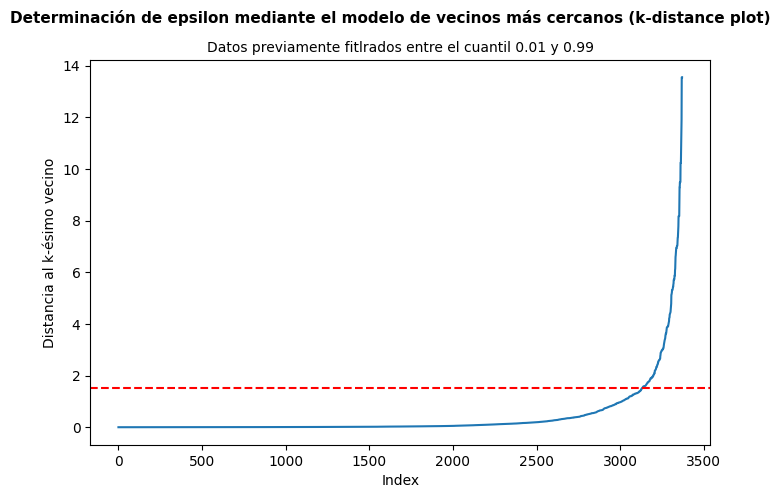

In [61]:
#Método del codo para la determinación de epsilon por distancia entre vecinos cercanos  - Se realizó con la base de datos filtrada
#Distancia para cada indice 18 vecinos (9 variables *2)
from sklearn.neighbors import NearestNeighbors
min_samples = 18

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(df_scaled_filtrado)

distances, indices = neighbors_fit.kneighbors(df_scaled_filtrado)
print(distances)
distances = np.sort(distances[:, -1])

plt.figure(figsize=(8,5))
plt.plot(distances)
plt.suptitle("Determinación de epsilon mediante el modelo de vecinos más cercanos (k-distance plot)", fontweight="bold",fontsize=11)
plt.title("Datos previamente fitlrados entre el cuantil 0.01 y 0.99", fontsize=10)
plt.xlabel("Indice")
plt.axhline(y=1.5,color="red",linestyle="--")
plt.xlabel("Index")
plt.ylabel("Distancia al k-ésimo vecino")
plt.show()

Con base en el diagrama se determino que para el numéro de vecinos igual a 18 la distancia epsilon más adecuada es 1.5.

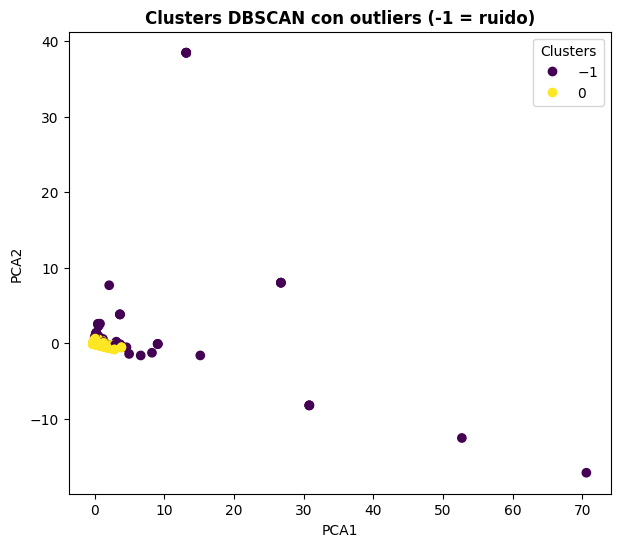

In [62]:
from sklearn.cluster import DBSCAN

dbscan =DBSCAN(eps=1.5, min_samples=18)
labels_dbscan_con_outliers=dbscan.fit_predict(df_scaled)
df_scaled_clusters["Cluster DBSCAN con outliers"] = labels_dbscan_con_outliers

# Visualización
plt.figure(figsize=(7,6))
scatter=plt.scatter(x=df_pca.iloc[:,0], y=df_pca.iloc[:,1], c=df_scaled_clusters["Cluster DBSCAN con outliers"])
plt.title("Clusters DBSCAN con outliers (-1 = ruido)", fontweight="bold")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

In [63]:
pd.Series(labels_dbscan_con_outliers).value_counts()

,count
0,3461
-1,58


#### ***6.3.2 Clusterización DBSCAN sin outliers***

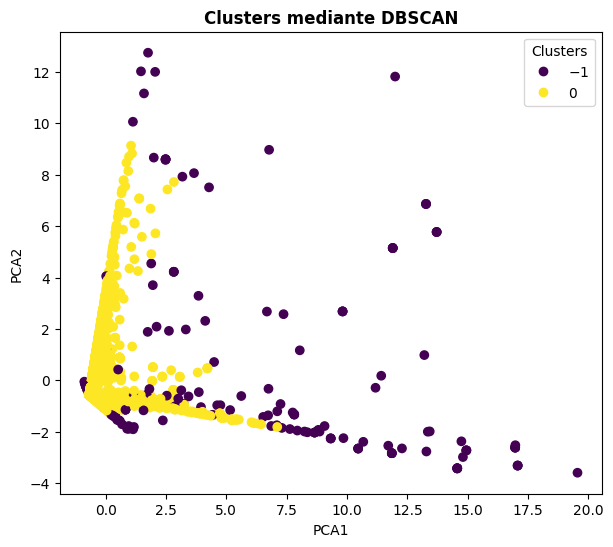

In [64]:
dbscan_filtrado =DBSCAN(eps=1.5, min_samples=18)
labels_dbscan_sin_outliers=dbscan_filtrado.fit_predict(df_scaled_filtrado)
df_scaled_filtrado_clusters["Cluster DBSCAN sin outliers"] = labels_dbscan_sin_outliers


# Visualización
plt.figure(figsize=(7,6))
scatter=plt.scatter(x=df_pca_filtrado.iloc[:,0], y=df_pca_filtrado.iloc[:,1], c=df_scaled_filtrado_clusters["Cluster DBSCAN sin outliers"])
plt.title("Clusters mediante DBSCAN", fontweight="bold")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

In [65]:
pd.Series(labels_dbscan_sin_outliers).value_counts().sort_index()

,count
-1,167
0,3204


In [66]:
#Si la clusterización se realizara quitando lo que identifica como ruido
#dbscan =DBSCAN(eps=15, min_samples=18)
#labels_dbscan=dbscan.fit_predict(df_scaled)
#mask = labels_dbscan != -1

#df_dbscan_sin_ruido = df_scaled[mask]
#labels_dbscan_sin_ruido = labels_dbscan[mask]

#pca = PCA(n_components=2)
#df_pca_sin_ruido = pca.fit_transform(df_dbscan_sin_ruido)

 #Visualización
#plt.figure(figsize=(8,6))
#scatter=plt.scatter(x=df_pca_sin_ruido[:,0], y=df_pca_sin_ruido[:,1], c=labels_dbscan_sin_ruido)
#plt.title("Clusters DBSCAN sin outliers (-1 = ruido)", fontweight="bold")
#plt.xlabel("PCA1")
#plt.ylabel("PCA2")
#plt.legend(*scatter.legend_elements(), title="Clusters")
#plt.show()

Mediante el método de DBSCAN se determina que solo se forma un grupo mayoritario (con 3204 registros) y 167 puntos categorizados como ruido.

### ***6.4 Clustering Gaussian Mixture Model (GMM):***

El modelo de mezcla gaussiana (GMM) es una técnica de agrupamiento probabilístico que modela datos como una combinación de múltiples distribuciones gaussianas.

Se utilizó el criterio de infomación bayesiano para la definición del número de clusters más recomendado para GMM.

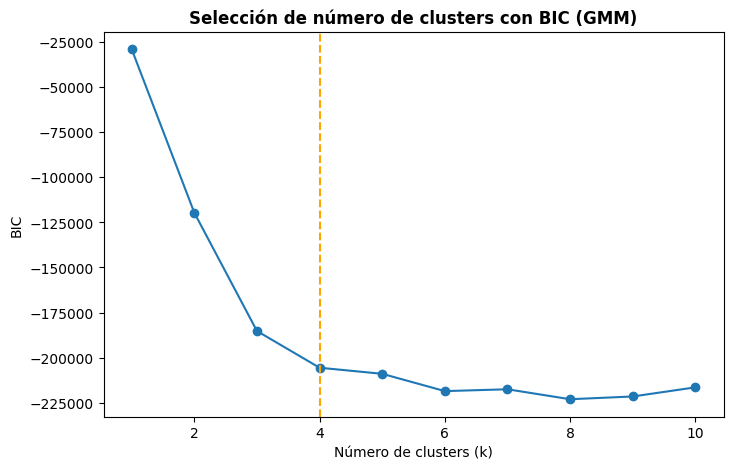

In [67]:
#Selección de clusters usando BIC (Bayesian Information Criterion - Criterio de Información Bayesiano) en la base de datos filtrada
from sklearn.mixture import GaussianMixture

bic = []
k_range = range(1, 11)

for k in k_range:
    gmm_BIC = GaussianMixture(n_components=k, random_state=42)
    gmm_BIC.fit(df_scaled_filtrado)
    bic.append(gmm_BIC.bic(df_scaled_filtrado))

plt.figure(figsize=(8,5))
plt.plot(k_range, bic, marker='o')
plt.title("Selección de número de clusters con BIC (GMM)", fontweight="bold")
plt.xlabel("Número de clusters (k)")
plt.axvline(x=4,color="orange",linestyle="--")
plt.ylabel("BIC")
plt.show()

Mediante el criterio de información bayesiano se identifica que se recomienda crear 4 clusters mediante el modelo de mezca gausiano.

#### ***6.4.1 Clusterización Gaussian Mixture Model (GMM) con outliers:***

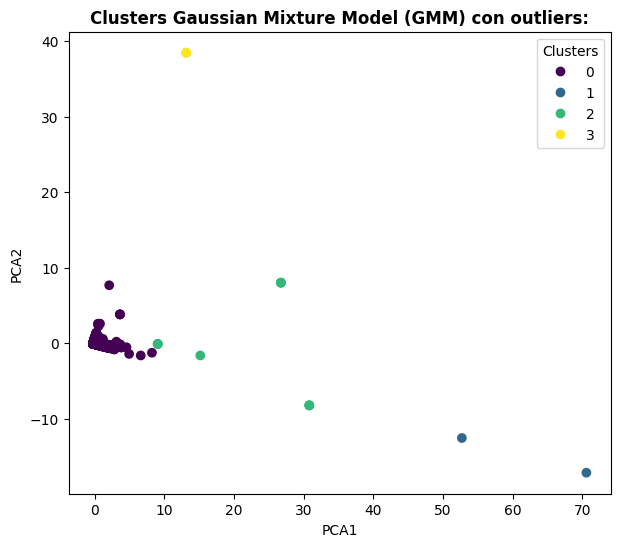

In [68]:
gmm = GaussianMixture(n_components=4, random_state=0)
labels_gmm_con_outliers = gmm.fit_predict(df_scaled)
df_scaled_clusters['Cluster GMM con outliers'] = labels_gmm_con_outliers


# Visualización
plt.figure(figsize=(7,6))
scatter=plt.scatter(x=df_pca.iloc[:,0], y=df_pca.iloc[:,1], c=df_scaled_clusters["Cluster GMM con outliers"])
plt.title("Clusters Gaussian Mixture Model (GMM) con outliers:", fontweight="bold")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

In [69]:
pd.Series(labels_gmm_con_outliers).value_counts()

,count
0,3503
2,10
3,4
1,2


#### ***6.4.2 Clusterización Gaussian Mixture Model (GMM) sin outliers:***

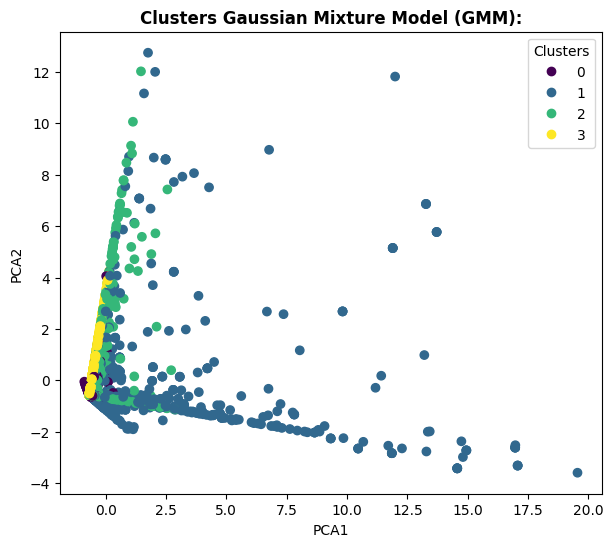

In [70]:
gmm_filtrado = GaussianMixture(n_components=4, random_state=0)
labels_gmm_sin_outliers = gmm_filtrado.fit_predict(df_scaled_filtrado)
df_scaled_filtrado_clusters['Cluster GMM sin outliers'] = labels_gmm_sin_outliers

# Visualización
plt.figure(figsize=(7,6))
scatter=plt.scatter(x=df_pca_filtrado.iloc[:,0], y=df_pca_filtrado.iloc[:,1], c=df_scaled_filtrado_clusters["Cluster GMM sin outliers"])
plt.title("Clusters Gaussian Mixture Model (GMM):", fontweight="bold")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

In [71]:
pd.Series(labels_gmm_sin_outliers).value_counts().sort_index()

,count
0,330
1,556
2,863
3,1622


El modelo de mezcla gausiano permite crear 4 clusters sin embargo no se evidencia la caracteristica de heterogeneidad externa que deben tener los clusters, y de manera interna también presentan dispersión entre los mismo clusters.

## **Paso 7: Evaluación de modelos:**

In [72]:
df_scaled.shape
df_scaled.head()


,Volumen de agua total utilizada por el establecimiento (m3/año),Volumen total de aguas residuales generadas por el establecimiento (m3/año),Volumen de agua residual tratada y vertida (m3/año),Volumen de agua residual vertida sin tratamiento (a+b),a. Volumen de agua vertida sin tratamiento. Sistemas de Alcantarillado (m3/año),b. Volumen de agua vertida sin tratamiento a otro medio receptor (m3/año),Volumen de agua residual entregado a un tercero para su tratamiento (m3/año),Volumen de agua residual tratada por el establecimiento (m3/año),Volumen de agua recirculada por el establecimiento (m3/año)
0,0.000650,0.055907,0.065538,-0.068660,-0.296475,-0.042966,0.012691,0.062655,-0.077859
1,-0.117844,-0.096447,-0.087661,-0.066313,-0.269522,-0.042966,-0.079373,-0.089374,-0.077859
2,-0.116505,-0.095583,-0.087661,-0.059624,-0.192694,-0.042966,-0.079373,-0.089374,-0.077859
3,-0.114498,-0.091854,-0.087661,-0.052658,-0.112683,-0.042966,0.061879,-0.089374,-0.077859
4,-0.118065,-0.096750,-0.087661,-0.068660,-0.296475,-0.042966,-0.079373,-0.089374,-0.077859


In [73]:
df_scaled_clusters.shape
df_scaled_clusters.head()

,Volumen de agua total utilizada por el establecimiento (m3/año),Volumen total de aguas residuales generadas por el establecimiento (m3/año),Volumen de agua residual tratada y vertida (m3/año),Volumen de agua residual vertida sin tratamiento (a+b),a. Volumen de agua vertida sin tratamiento. Sistemas de Alcantarillado (m3/año),b. Volumen de agua vertida sin tratamiento a otro medio receptor (m3/año),Volumen de agua residual entregado a un tercero para su tratamiento (m3/año),Volumen de agua residual tratada por el establecimiento (m3/año),Volumen de agua recirculada por el establecimiento (m3/año),Cluster KMeans,Cluster Jerarquico con outliers,Cluster DBSCAN con outliers,Cluster GMM con outliers
0,0.000650,0.055907,0.065538,-0.068660,-0.296475,-0.042966,0.012691,0.062655,-0.077859,0,1,0,0
1,-0.117844,-0.096447,-0.087661,-0.066313,-0.269522,-0.042966,-0.079373,-0.089374,-0.077859,0,1,0,0
2,-0.116505,-0.095583,-0.087661,-0.059624,-0.192694,-0.042966,-0.079373,-0.089374,-0.077859,0,1,0,0
3,-0.114498,-0.091854,-0.087661,-0.052658,-0.112683,-0.042966,0.061879,-0.089374,-0.077859,0,1,0,0
4,-0.118065,-0.096750,-0.087661,-0.068660,-0.296475,-0.042966,-0.079373,-0.089374,-0.077859,0,1,0,0


In [74]:
df_scaled_filtrado.shape
df_scaled_filtrado.head()


,Volumen de agua total utilizada por el establecimiento (m3/año),Volumen total de aguas residuales generadas por el establecimiento (m3/año),Volumen de agua residual tratada y vertida (m3/año),Volumen de agua residual vertida sin tratamiento (a+b),a. Volumen de agua vertida sin tratamiento. Sistemas de Alcantarillado (m3/año),b. Volumen de agua vertida sin tratamiento a otro medio receptor (m3/año),Volumen de agua residual entregado a un tercero para su tratamiento (m3/año),Volumen de agua residual tratada por el establecimiento (m3/año),Volumen de agua recirculada por el establecimiento (m3/año)
0,0.683573,1.086277,1.102923,-0.483706,-0.476508,-0.113679,0.886456,1.065926,-0.166632
1,-0.307451,-0.274503,-0.253764,-0.425025,-0.417879,-0.113679,-0.193202,-0.261826,-0.166632
2,-0.296257,-0.266789,-0.253764,-0.257762,-0.250765,-0.113679,-0.193202,-0.261826,-0.166632
3,-0.279465,-0.233485,-0.253764,-0.083568,-0.076725,-0.113679,1.463298,-0.261826,-0.166632
4,-0.309297,-0.277209,-0.253764,-0.483706,-0.476508,-0.113679,-0.193202,-0.261826,-0.166632


In [75]:
df_scaled_filtrado_clusters.shape
df_scaled_filtrado_clusters.head()


,Volumen de agua total utilizada por el establecimiento (m3/año),Volumen total de aguas residuales generadas por el establecimiento (m3/año),Volumen de agua residual tratada y vertida (m3/año),Volumen de agua residual vertida sin tratamiento (a+b),a. Volumen de agua vertida sin tratamiento. Sistemas de Alcantarillado (m3/año),b. Volumen de agua vertida sin tratamiento a otro medio receptor (m3/año),Volumen de agua residual entregado a un tercero para su tratamiento (m3/año),Volumen de agua residual tratada por el establecimiento (m3/año),Volumen de agua recirculada por el establecimiento (m3/año),Cluster Kmeans sin outliers,Cluster Jerarquico sin outliers,Cluster DBSCAN sin outliers,Cluster GMM sin outliers
0,0.683573,1.086277,1.102923,-0.483706,-0.476508,-0.113679,0.886456,1.065926,-0.166632,2,0,0,1
1,-0.307451,-0.274503,-0.253764,-0.425025,-0.417879,-0.113679,-0.193202,-0.261826,-0.166632,2,0,0,3
2,-0.296257,-0.266789,-0.253764,-0.257762,-0.250765,-0.113679,-0.193202,-0.261826,-0.166632,2,0,0,3
3,-0.279465,-0.233485,-0.253764,-0.083568,-0.076725,-0.113679,1.463298,-0.261826,-0.166632,2,0,0,1
4,-0.309297,-0.277209,-0.253764,-0.483706,-0.476508,-0.113679,-0.193202,-0.261826,-0.166632,2,0,0,3


#### ***7.1 Definición de función de evaluación de modelos sin outliers (base filtrada):***

Se utilizaron dos métodos para evaluar los modelos: Silhouette y Davies Bouldin.Estos métodos miden:

* **Silhouette:** El coeficiente de Silhouette mide qué tan bien encaja cada punto de datos dentro de su grupo asignado (similitud con su propio cluster) y qué tan bien separado está de otros grupos. El coeficiente de Silhouette varía de -1 a 1:
  * +1 significa que el punto está idealmente agrupado — está mucho más cerca de los puntos de su propio grupo que de los puntos del grupo más cercano.
  * 0 sugiere que el punto está en el límite entre grupos y que en realidad no pertenecen a ningún grupo en particular.
  * -1 significa que ha sido clasificado erróneamente — está más cerca de otro grupo que del suyo y por lo tanto están mezclados.

* **Davies-Bouldin:** mide el nivel de compactación de los datos y lo compara con la separación entre clusters.
  * Entre más bajo el valor los clusters están bien definidos
  * Entre más alto el valor,indica que los clusters están sobrepuestos.


In [76]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

def evaluacion_modelo(base,labels,nombre_metodo):
      if len(set(labels)) > 1 and -1 not in set(labels):
        sil= silhouette_score(base,labels)
        db = davies_bouldin_score(base, labels)
        print(f"Evaluación de {nombre_metodo}")
        print(f"Silhouette: {sil:.3f}")
        print(f"Davies-Bouldin: {db:.3f}")
        print("-"*30)

def evaluacion_modelo_dbscan_sin_ruido(base, labels, nombre_metodo):
    mask = labels != -1      # Filtro de ruido de DBSCAN
    dbscan_filtrado = base[mask] #filtro a la base de datos
    labels_dbscan_filtrado = labels[mask] #filtro a labels

    if len(set(labels_dbscan_filtrado)) > 1:
        sil = silhouette_score(dbscan_filtrado, labels_dbscan_filtrado)
        db = davies_bouldin_score(dbscan_filtrado, labels_dbscan_filtrado)
        print(f"Evaluación de {nombre_metodo}")
        print(f"Silhouette: {sil:.3f}")
        print(f"Davies-Bouldin: {db:.3f}")
        print("-"*30)
    else:
        print(f"{nombre_metodo}: no tiene suficientes clusters válidos")


#### ***7.2 Ealuación de modelos sin outliers (base filtrada):***

In [77]:
evaluacion_modelo(df_scaled_filtrado, labels_kmeans_sin_outliers, "KMeans:")
evaluacion_modelo(df_scaled_filtrado, labels_jerarquico_sin_outliers, "Jerárquico:")
evaluacion_modelo(df_scaled_filtrado, labels_gmm_sin_outliers, "GMM:")
evaluacion_modelo_dbscan_sin_ruido(df_scaled_filtrado, labels_dbscan_sin_outliers, "DBSCAN:")

Evaluación de KMeans:
Silhouette: 0.736
Davies-Bouldin: 0.706
------------------------------
Evaluación de Jerárquico:
Silhouette: 0.744
Davies-Bouldin: 0.661
------------------------------
Evaluación de GMM:
Silhouette: 0.040
Davies-Bouldin: 3.353
------------------------------
DBSCAN:: no tiene suficientes clusters válidos


De acuerdo a los métodos de evaluación, el modelo que mejor presenta coeficiente de Silhouette y Davies Bouldin es el modelo jerárquico.

## **Paso 8: Análisis de los clusters generados:**

In [78]:
df_scaled_filtrado_clusters.groupby("Cluster Jerarquico sin outliers").mean().round(2)

,Volumen de agua total utilizada por el establecimiento (m3/año),Volumen total de aguas residuales generadas por el establecimiento (m3/año),Volumen de agua residual tratada y vertida (m3/año),Volumen de agua residual vertida sin tratamiento (a+b),a. Volumen de agua vertida sin tratamiento. Sistemas de Alcantarillado (m3/año),b. Volumen de agua vertida sin tratamiento a otro medio receptor (m3/año),Volumen de agua residual entregado a un tercero para su tratamiento (m3/año),Volumen de agua residual tratada por el establecimiento (m3/año),Volumen de agua recirculada por el establecimiento (m3/año),Cluster Kmeans sin outliers,Cluster DBSCAN sin outliers,Cluster GMM sin outliers
Cluster Jerarquico sin outliers,,,,,,,,,,,,
0,-0.09,-0.10,-0.09,-0.09,-0.08,-0.10,-0.14,-0.10,-0.06,1.91,-0.02,2.20
1,-0.27,-0.24,-0.25,0.11,-0.33,7.45,-0.14,-0.25,-0.16,2.56,-0.53,0.00
2,5.87,7.29,7.32,-0.28,-0.27,-0.11,2.13,7.19,2.42,1.00,-1.00,1.00
3,1.15,1.04,0.78,5.66,5.66,-0.11,0.01,0.78,0.65,0.15,-0.40,1.42
4,3.42,1.73,1.61,2.93,2.93,-0.11,-0.19,4.09,14.51,0.83,-1.00,1.00
5,0.01,-0.09,-0.16,-0.39,-0.38,-0.11,5.83,-0.13,0.02,3.52,-0.34,1.00


Los clusters formados presentan las siguientes características:
* **Cluster 0:** Industrias con muy bajos niveles de consumo de agua y generación de agua residual
* **Cluster 1:** Industrias con altos volumenes de agua vertida sin tratamiento a otro medio receptor
* **Cluster 2:** Industrias con un alto consumo de agua, de generación de agua residual, la cual es tratada por el mismo establecimiento y vertida
* **Cluster 3:** Industrias con un bajo consumo de agua, bajo generación de agua residual la cual vierten al sistema de  alcantarillado sin tratar.
* **Cluster 4:**  Undustrias caracterizadas  por el moderado consumo de agua, la cual recirculan en gran proporción en el establecimiento y en baja proporción la vierten sin tratamiento.
* **Cluster 5:** Industrias con un bajo consumo de agua y generación de agua residual, sin embargo, la que generan, la entregan a un tercero para su tratamiento.